# Camera-Based Non-Invasive Traffic Sensing with YOLOv8: How Reliable Are Detector-Derived Counts and Traffic "Vital Signs"? (v4, final)

**Framing.** Traffic engineers separate *intrusive* sensors (in-road devices such as inductive loops) from *non-intrusive* ones. A roadside **camera** is a non-invasive traffic sensor: no road works, no contact with vehicles, and one device can observe many lanes. Turning video into traffic measurements (density, flow, speed) needs an object detector, and detectors make errors. This notebook is a **pre-registered reliability study of camera-based, non-invasive traffic sensing**: when and why do detector-derived counts fail, and how much do derived traffic "vital signs" change when the detector's operating point changes?

**How to use:** open in Google Colab, choose **Runtime -> Change runtime type -> T4 GPU**, then **Runtime -> Run all**. Nothing to upload, no Drive paths.

**Time budget (measured on your T4 where marked):**

| Step | Time |
|---|---|
| Highway detector training (100 epochs) | 13 min (measured) |
| Figures, video tracking, Studies A and B | about 15-25 min (estimate) |
| **VisDrone fine-tuning, 35 epochs at 960 px** | **about 2.1 h** (extrapolated from 1.19 h for 20 epochs, measured) |
| Study E (count metrics + mechanism grid, inference only) | about 15-30 min (estimate) |
| Study F (traffic vital signs, 12 tracking runs on one video) | about 5-10 min (estimate) |
| **Total** | **about 3.1-3.7 h: at or slightly above a 3.5 h limit** |

**To stay under 3.5 h:** set `FT_MAX_HOURS = 1.5` (hard cap; the training schedule rescales to fit) or `FT_IMGSZ = 800`. Consider `SAVE_TO_DRIVE = True` so a disconnect can be resumed instead of restarted. Keep the browser tab open.

---
## STATUS
Every code cell has an explanation above it.

| Part | Content | Status |
|---|---|---|
| 1 | Setup, dataset download, YOLOv8n fine-tuning, validation detections | done |
| 2 | Qualitative figures, merged into one paper-ready Figure 1 (2.5) | done |
| 3 | Study A: recall vs density on the highway dataset | run: not supported |
| 4 | Study B: VisDrone, 3 COCO detectors | run: partial |
| 5 | Study C: fine-tuned detector (35 epochs) + stratified density test | run (20 epochs): not supported; re-run with 35 |
| 6 | Study E: MAE/RMSE count metrics + mechanism test (NMS IoU, input size) | new in v3 |
| 7 | **Study F (new): camera-based traffic "vital signs" (density, flow, speed) and their sensitivity to detector settings** | new |
| 8 | Paper assets: merged Figure 2 and LaTeX tables (Figure 3 is written in Part 7) | done |
| 9 | Summary + export bundle | done |

*Data credit: F. Nekouei, Top-View Vehicle Detection Image Dataset (CC BY 4.0, frames from Pexels videos). VisDrone2019-DET: Tianjin University (check its licence before publishing).*

# Part 1 | Setup, data, model

### 1.1 Install libraries
`ultralytics` provides YOLOv8 (detection + tracking). `kagglehub` downloads the public dataset without any login.

In [1]:
!pip -q install ultralytics kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.7 MB/s eta 0:00:00


### 1.2 Imports and settings
All tunable settings live here.
- `CONF` is the detection confidence threshold for Parts 2 and 3 (the same 0.4 as the original demo).
- `CONF_VD` is the threshold for the off-the-shelf detectors in Part 4 (Ultralytics' default 0.25).
- `IOU_MATCH = 0.5` means a detection "finds" a ground-truth vehicle if their boxes overlap by IoU >= 0.5.
- `IMGSZ_VD = 1280` because VisDrone vehicles are tiny and 640 px would understate recall for every model.
- `SIZE_MIN = 32` px is the threshold for the robustness check that asks whether any density effect is just "small objects are hard".

In [2]:
import os, glob, shutil, zipfile, subprocess, urllib.request, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import cv2, torch
warnings.filterwarnings('ignore')
os.environ['WANDB_DISABLED'] = 'true'

# ------------------------------ SETTINGS ------------------------------
CONF       = 0.4      # detection threshold for figures + Study A
CONF_VD    = 0.25     # detection threshold for Study B (off-the-shelf detectors)
IOU_MATCH  = 0.5
EPOCHS     = 100      # same as the original tutorial notebook
SEED       = 0
MODELS_VD  = ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt']   # Study B detectors (auto-downloaded, COCO-pretrained)
IMGSZ_VD   = 1280
SIZE_MIN   = 32
RUN_FINETUNE = True   # Study C: fine-tune YOLOv8n on VisDrone TRAIN (about 2.1 h at 35 epochs)
FT_EPOCHS    = 35     # measured on a T4: about 3.2 min/epoch at 960 px, so about 2.1 h
FT_MAX_HOURS = None   # optional hard time cap in hours (e.g. 1.6). If set it overrides FT_EPOCHS and rescales the schedule
SAVE_TO_DRIVE = False # True: copy the fine-tuning checkpoint to Google Drive every epoch, so a disconnect can be resumed
FT_IMGSZ     = 960    # training and evaluation image size for the fine-tuned detector
# ----------------------------------------------------------------------
WORK    = os.path.abspath('project_work'); os.makedirs(WORK, exist_ok=True)
FIG_DIR = os.path.abspath('figures');      os.makedirs(FIG_DIR, exist_ok=True)
HAS_GPU = torch.cuda.is_available(); DEV = 0 if HAS_GPU else 'cpu'
print('GPU available:', HAS_GPU, '|', torch.cuda.get_device_name(0) if HAS_GPU else 'none')
if not HAS_GPU:
    EPOCHS = 15; MODELS_VD = MODELS_VD[:1]; RUN_FINETUNE = False
    print('>>> No GPU: switch Runtime to T4 GPU for the real run. Using 15 epochs and only yolov8n on CPU.')

GPU available: True | Tesla T4


### 1.3 Download the dataset from scratch
The dataset has 536 training and 90 validation top-view highway frames (single class "Vehicle"), plus a sample image and sample video. The code downloads it with `kagglehub` (falling back to a direct URL), locates the folder that contains `train/` and `valid/`, and writes our own `data.yaml` with **absolute paths** so that nobody has path problems.

In [3]:
def find_dataset_root(base):
    for dp, dn, fn in os.walk(base):
        if os.path.isdir(os.path.join(dp, 'train', 'images')) and (
           os.path.isdir(os.path.join(dp, 'valid', 'images')) or os.path.isdir(os.path.join(dp, 'val', 'images'))):
            return dp
    return None

DATASET_ROOT = None
try:
    import kagglehub
    DATASET_ROOT = find_dataset_root(kagglehub.dataset_download('farzadnekouei/top-view-vehicle-detection-image-dataset'))
except Exception as e:
    print('kagglehub failed (', type(e).__name__, ') -> direct download')
if DATASET_ROOT is None:
    url = 'https://www.kaggle.com/api/v1/datasets/download/farzadnekouei/top-view-vehicle-detection-image-dataset?dataset_version_number=2'
    zpath = os.path.join(WORK, 'vehicle_dataset.zip'); urllib.request.urlretrieve(url, zpath)
    ex = os.path.join(WORK, 'vehicle_dataset')
    with zipfile.ZipFile(zpath) as z: z.extractall(ex)
    DATASET_ROOT = find_dataset_root(ex)
assert DATASET_ROOT, 'Could not download/locate the dataset (check internet access).'

VAL_DIR = 'valid' if os.path.isdir(os.path.join(DATASET_ROOT, 'valid', 'images')) else 'val'
import yaml
DATA_YAML = os.path.join(WORK, 'data_abs.yaml')
with open(DATA_YAML, 'w') as f:
    yaml.dump({'path': DATASET_ROOT, 'train': 'train/images', 'val': f'{VAL_DIR}/images', 'nc': 1, 'names': {0: 'Vehicle'}}, f)
def find_first(name):
    h = glob.glob(os.path.join(DATASET_ROOT, '**', name), recursive=True); return h[0] if h else None
SAMPLE_IMG, SAMPLE_VID = find_first('sample_image.jpg'), find_first('sample_video.mp4')
n_tr = len(glob.glob(f'{DATASET_ROOT}/train/images/*')); n_va = len(glob.glob(f'{DATASET_ROOT}/{VAL_DIR}/images/*'))
print(f'Dataset root: {DATASET_ROOT}\ntrain images: {n_tr} | validation images: {n_va}\nsample image: {SAMPLE_IMG}\nsample video: {SAMPLE_VID}')

Using Colab cache for faster access to the 'top-view-vehicle-detection-image-dataset' dataset.
Dataset root: /kaggle/input/top-view-vehicle-detection-image-dataset/Vehicle_Detection_Image_Dataset
train images: 536 | validation images: 90
sample image: /kaggle/input/top-view-vehicle-detection-image-dataset/Vehicle_Detection_Image_Dataset/sample_image.jpg
sample video: /kaggle/input/top-view-vehicle-detection-image-dataset/Vehicle_Detection_Image_Dataset/sample_video.mp4


### 1.4 Fine-tune YOLOv8n (transfer learning)
We start from the COCO-pretrained `yolov8n.pt` (smallest and fastest YOLOv8) and fine-tune it on the single class "Vehicle" with the same hyper-parameters as the original tutorial (100 epochs, batch 32, lr0 = 1e-4, dropout 0.1, seed 0). If a trained `best.pt` already exists in this runtime, it is re-used and training is skipped. Expected result: mAP50 about 0.97 on validation.

In [4]:
from ultralytics import YOLO
existing = sorted(glob.glob(os.path.join(WORK, 'runs', '**', 'best.pt'), recursive=True))
if existing:
    BEST = existing[0]; print('Re-using trained weights:', BEST)
else:
    model = YOLO('yolov8n.pt')
    model.train(data=DATA_YAML, epochs=EPOCHS, imgsz=640, device=DEV, patience=50, batch=32 if HAS_GPU else 8,
                optimizer='auto', lr0=0.0001, lrf=0.1, dropout=0.1, seed=SEED,
                project=os.path.join(WORK, 'runs'), name='train', exist_ok=True, plots=False, verbose=False)
    BEST = str(model.trainer.best)
    if not os.path.exists(BEST):
        BEST = sorted(glob.glob(os.path.join(WORK, 'runs', '**', 'best.pt'), recursive=True))[0]
    print('Training finished:', BEST)
best_model = YOLO(BEST)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project_work/data_abs.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fractio

### 1.5 Shared helper functions (used by every later part)
- `iou_matrix`, `match2`, `match_greedy`: one-to-one matching of detections to ground truth. A ground-truth vehicle counts as **found** (recall) if some detection overlaps it by IoU >= 0.5; each detection can match only one vehicle.
- `gt_features`: per-vehicle covariates computed from ground truth: **size** (sqrt of box area), **occl** (largest fraction of the box covered by another box), **nbrs** (how many other vehicles lie within 2 box-sizes).
- `wilson`: 95% confidence interval for a proportion (used on every recall bar/curve).
- `load_gt`: reads YOLO-format label files into pixel boxes. `run_detector`: runs a model once at a very low confidence floor, so any threshold can be applied afterwards.

In [5]:
def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0: return np.zeros((len(a), len(b)))
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); ab = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (aa[:, None] + ab[None, :] - inter + 1e-9)

def match2(gt, pb, pc, thr=IOU_MATCH):
    """Greedy one-to-one matching, highest-confidence detection first. Returns (gt_found, pred_matched)."""
    gt_hit = np.zeros(len(gt), bool); pr_ok = np.zeros(len(pb), bool)
    if len(gt) == 0 or len(pb) == 0: return gt_hit, pr_ok
    M = iou_matrix(pb, gt)
    for j in np.argsort(-pc):
        cand = np.where(~gt_hit)[0]
        if len(cand) == 0: break
        k = cand[np.argmax(M[j, cand])]
        if M[j, k] >= thr: gt_hit[k] = True; pr_ok[j] = True
    return gt_hit, pr_ok

def match_greedy(gt, pb, pc, thr=IOU_MATCH): return match2(gt, pb, pc, thr)[0]

def gt_features(gt):
    n = len(gt)
    if n == 0: return pd.DataFrame(columns=['size', 'occl', 'nbrs'])
    w = gt[:, 2] - gt[:, 0]; h = gt[:, 3] - gt[:, 1]; area = np.clip(w * h, 1, None); size = np.sqrt(area)
    cx = (gt[:, 0] + gt[:, 2]) / 2; cy = (gt[:, 1] + gt[:, 3]) / 2
    x1 = np.maximum(gt[:, None, 0], gt[None, :, 0]); y1 = np.maximum(gt[:, None, 1], gt[None, :, 1])
    x2 = np.minimum(gt[:, None, 2], gt[None, :, 2]); y2 = np.minimum(gt[:, None, 3], gt[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None); np.fill_diagonal(inter, 0)
    d = np.hypot(cx[:, None] - cx[None, :], cy[:, None] - cy[None, :]); np.fill_diagonal(d, np.inf)
    return pd.DataFrame({'size': size, 'occl': (inter / area[:, None]).max(1), 'nbrs': (d < 2.0 * size[:, None]).sum(1)})

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n; c = (p + z*z/(2*n)) / den; hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return c - hw, c + hw

from PIL import Image
img_dir = f'{DATASET_ROOT}/{VAL_DIR}/images'; lbl_dir = f'{DATASET_ROOT}/{VAL_DIR}/labels'
def load_gt(p):
    W, H = Image.open(p).size; lf = os.path.join(lbl_dir, os.path.splitext(os.path.basename(p))[0] + '.txt'); b = []
    if os.path.exists(lf):
        for line in open(lf):
            q = line.split()
            if len(q) == 5:
                xc, yc, w, h = map(float, q[1:5]); b.append([(xc-w/2)*W, (yc-h/2)*H, (xc+w/2)*W, (yc+h/2)*H])
            elif len(q) > 5 and (len(q) - 1) % 2 == 0:     # polygon label -> bounding box
                xs = np.array(q[1::2], float) * W; ys = np.array(q[2::2], float) * H; b.append([xs.min(), ys.min(), xs.max(), ys.max()])
    return np.array(b, float).reshape(-1, 4)

def run_detector(model, paths, conf_floor=0.05, batch=16, **kw):
    out = []
    for i in range(0, len(paths), batch):
        for r in model.predict(source=paths[i:i+batch], conf=conf_floor, verbose=False, device=DEV, **kw):
            out.append((r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy()))
    return out

### 1.6 Ground truth and detections on the validation split
We load the ground-truth boxes of the 90 validation images and run the fine-tuned model **once** at confidence floor 0.05. Everything downstream (figures, Study A) re-uses these detections and just applies a threshold. **Only the validation split is analysed**, because the model was trained on the train split, so recall there would be inflated.

In [6]:
img_paths = sorted(p for p in glob.glob(img_dir + '/*') if p.lower().endswith(('.jpg', '.jpeg', '.png')))
val_names = [os.path.basename(p) for p in img_paths]
gts = [load_gt(p) for p in img_paths]
val_det = run_detector(best_model, img_paths, imgsz=640)
cnt = np.array([len(g) for g in gts])
print(f'{len(img_paths)} validation images | vehicles per image: min {cnt.min()}, median {int(np.median(cnt))}, max {cnt.max()}, total {cnt.sum()}')

90 validation images | vehicles per image: min 1, median 7, max 33, total 937


# Part 2 | Qualitative results (figures for the paper)

### 2.1 Drawing helpers
Functions that draw the four figures. Colour code for detection quality: **green** = ground truth found, **blue** = correct detection, **red (thick)** = missed vehicle, **orange dashed** = false positive. Tracks are coloured by track id.

In [7]:
C_GT, C_TP, C_MISS, C_FP = '#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'

def add_boxes(ax, boxes, color, lw=1.5, ls='-'):
    for x1, y1, x2, y2 in boxes:
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=color, lw=lw, ls=ls))

def fig_gallery(items, path, ncols=3):
    nrows = int(np.ceil(len(items) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows)); axs = np.atleast_1d(axs).ravel()
    for ax, it in zip(axs, items):
        keep = it['pc'] >= CONF; pb = it['pb'][keep]; pc = it['pc'][keep]
        hit, ok = match2(it['gt'], pb, pc)
        ax.imshow(it['img']); ax.axis('off')
        add_boxes(ax, it['gt'][hit], C_GT, 1.0); add_boxes(ax, pb[ok], C_TP, 2.0)
        add_boxes(ax, it['gt'][~hit], C_MISS, 3.0); add_boxes(ax, pb[~ok], C_FP, 2.0, '--')
        ax.set_title(f"{len(it['gt'])} vehicles | detected {int(ok.sum())} | missed {int((~hit).sum())} | false pos. {int((~ok).sum())}", fontsize=11)
    for ax in axs[len(items):]: ax.axis('off')
    handles = [Line2D([0], [0], color=C_GT, lw=1.5, label='ground truth (found)'), Line2D([0], [0], color=C_TP, lw=2, label='correct detection'),
               Line2D([0], [0], color=C_MISS, lw=3, label='missed vehicle'), Line2D([0], [0], color=C_FP, lw=2, ls='--', label='false positive')]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=12, frameon=False)
    plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.savefig(path, dpi=200, bbox_inches='tight'); plt.show()

def fig_side_by_side(imgs, titles, path):
    fig, axs = plt.subplots(1, len(imgs), figsize=(9 * len(imgs), 8))
    for ax, im, t in zip(np.atleast_1d(axs), imgs, titles): ax.imshow(im); ax.set_title(t, fontsize=14); ax.axis('off')
    plt.tight_layout(); plt.savefig(path, dpi=200, bbox_inches='tight'); plt.show()

def id_color(i): return plt.cm.hsv((i * 0.618033) % 1.0)

def fig_trails(frames, boxes_at, hist, path, trail=45):
    fs = sorted(frames); fig, axs = plt.subplots(1, len(fs), figsize=(6.5 * len(fs), 4.6)); axs = np.atleast_1d(axs)
    for ax, f in zip(axs, fs):
        ax.imshow(frames[f]); ax.axis('off'); xyxy, ids = boxes_at[f]
        for b, i in zip(xyxy, ids):
            ax.add_patch(Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec=id_color(int(i)) if i >= 0 else 'w', lw=1.6))
        for i, pts in hist.items():
            seg = [(cx, cy) for (ff, cx, cy) in pts if f - trail <= ff <= f]
            if len(seg) >= 2: s = np.array(seg); ax.plot(s[:, 0], s[:, 1], '-', color=id_color(i), lw=2.2, alpha=.9)
        ax.set_title(f'frame {f}  |  {len(xyxy)} vehicles', fontsize=12)
    plt.tight_layout(); plt.savefig(path, dpi=200, bbox_inches='tight'); plt.show()

def fig_density(bg, centers, counts, fps, path):
    from scipy.ndimage import gaussian_filter
    Hh, W = bg.shape[:2]; cx, cy = np.array(centers).T
    Hm, _, _ = np.histogram2d(cx, cy, bins=[max(W // 16, 8), max(Hh // 16, 8)], range=[[0, W], [0, Hh]]); Hm = gaussian_filter(Hm.T, 2)
    fig, ax = plt.subplots(1, 2, figsize=(17, 5.2), gridspec_kw={'width_ratios': [1.2, 1]})
    ax[0].imshow(bg); im = ax[0].imshow(Hm, extent=[0, W, Hh, 0], cmap='inferno', alpha=.55); ax[0].axis('off')
    ax[0].set_title('Where vehicles concentrate (all frames)', fontsize=13); plt.colorbar(im, ax=ax[0], fraction=.03, label='detection density')
    t = np.arange(len(counts)) / fps; c = np.array(counts, float)
    ax[1].plot(t, c, color='#9ecae1', lw=1, label='per frame'); w = min(15, max(len(c) // 5, 1))
    ax[1].plot(t, np.convolve(c, np.ones(w) / w, mode='same'), color='#08519c', lw=2.5, label=f'{w}-frame mean')
    ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('vehicles detected'); ax[1].set_title('Traffic density over time', fontsize=13)
    ax[1].grid(alpha=.3); ax[1].legend(); plt.tight_layout(); plt.savefig(path, dpi=200, bbox_inches='tight'); plt.show()

### 2.2 Figure 1: detection gallery from sparse to dense traffic
Six validation images are chosen at the 10th, 35th, 55th, 75th, 90th and 100th percentile of **vehicle count**, i.e. selected only by how crowded they are, **not by how well the model did** (no cherry-picking). Each title reports vehicles, detections, misses and false positives, so failures stay visible.

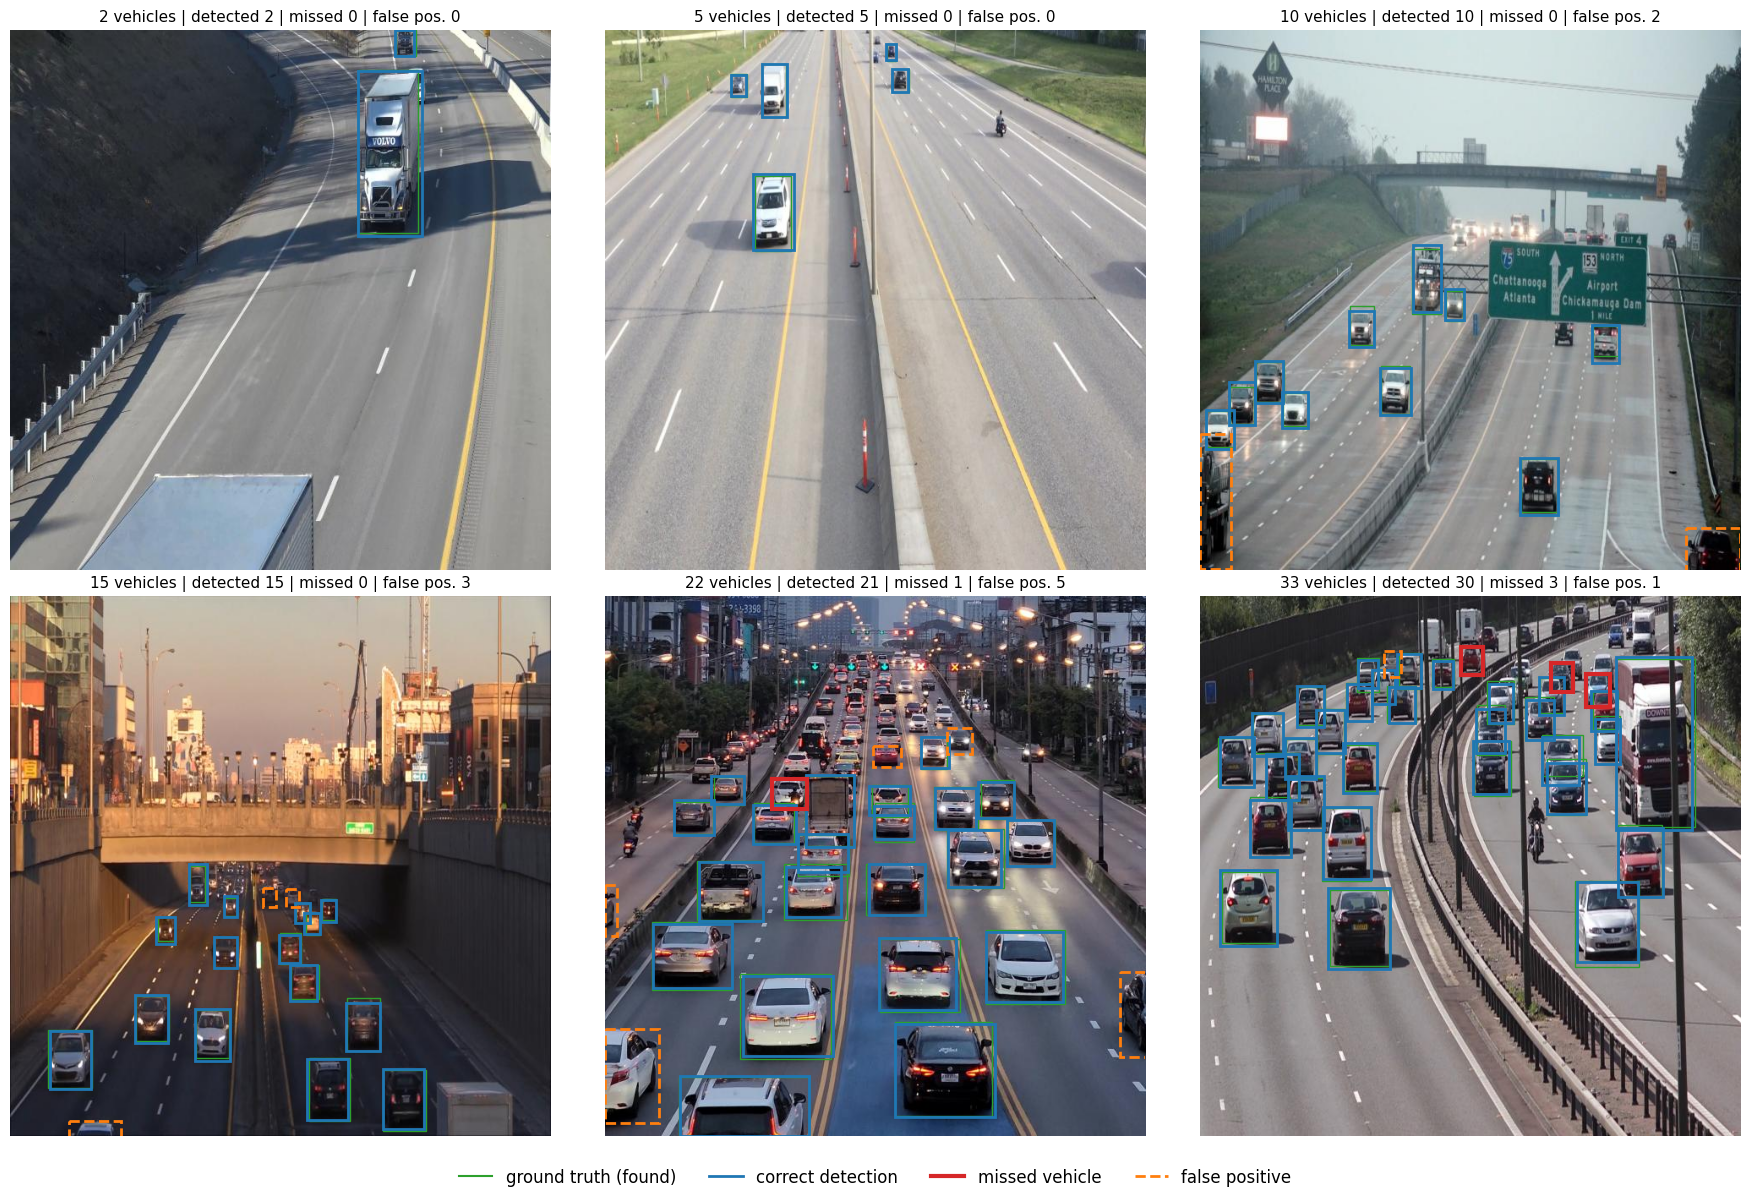

In [8]:
order = np.argsort(cnt, kind='stable')
pick = [order[int(q * (len(order) - 1))] for q in [0.10, 0.35, 0.55, 0.75, 0.90, 1.0]]
items = [dict(img=cv2.cvtColor(cv2.imread(img_paths[k]), cv2.COLOR_BGR2RGB), gt=gts[k], pb=val_det[k][0], pc=val_det[k][1]) for k in pick]
fig_gallery(items, os.path.join(FIG_DIR, 'fig1_detection_gallery.png'))
PAPER = {'gallery': items}   # kept for the merged paper Figure 1 (section 2.5)

### 2.3 Figure 2: COCO-pretrained vs fine-tuned
The same sample image through (a) the generic COCO-pretrained YOLOv8n restricted to car/bus/truck and (b) our fine-tuned model. This shows the value of domain-specific fine-tuning on top-view imagery.

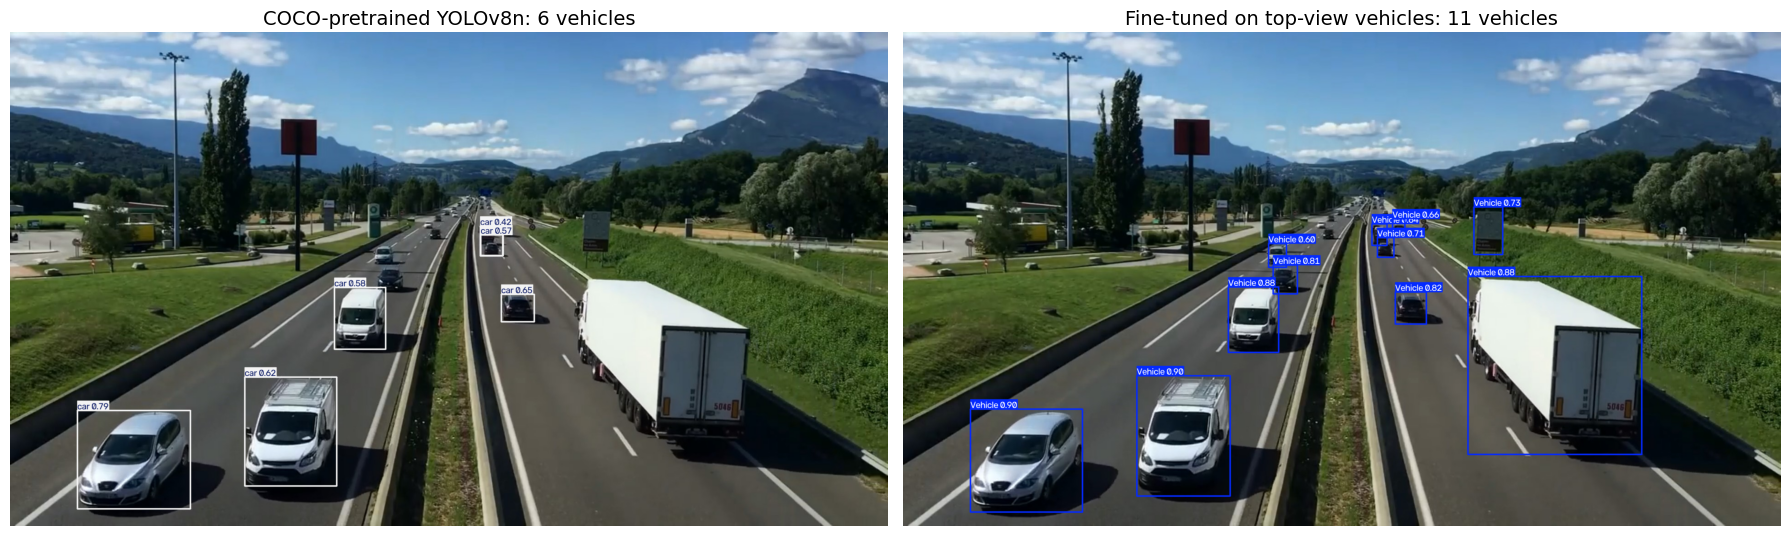

In [9]:
if SAMPLE_IMG:
    pre = YOLO('yolov8n.pt')
    r0 = pre.predict(SAMPLE_IMG, imgsz=640, conf=CONF, classes=[2, 5, 7], verbose=False, device=DEV)[0]
    r1 = best_model.predict(SAMPLE_IMG, imgsz=640, conf=CONF, verbose=False, device=DEV)[0]
    fig_side_by_side([cv2.cvtColor(r0.plot(line_width=2), cv2.COLOR_BGR2RGB), cv2.cvtColor(r1.plot(line_width=2), cv2.COLOR_BGR2RGB)],
                     [f'COCO-pretrained YOLOv8n: {len(r0.boxes)} vehicles', f'Fine-tuned on top-view vehicles: {len(r1.boxes)} vehicles'],
                     os.path.join(FIG_DIR, 'fig2_pretrained_vs_finetuned.png'))
    PAPER['pre'] = dict(img=cv2.cvtColor(r0.orig_img, cv2.COLOR_BGR2RGB), boxes=r0.boxes.xyxy.cpu().numpy())
    PAPER['ft'] = dict(img=cv2.cvtColor(r1.orig_img, cv2.COLOR_BGR2RGB), boxes=r1.boxes.xyxy.cpu().numpy())
else:
    print('sample_image.jpg not found; skipping Fig 2.')

### 2.4 Figures 3 and 4: vehicle tracking and traffic density on the sample video
`track_stream` runs YOLOv8 + **ByteTrack** frame by frame and yields boxes with track ids (with a simple centroid-tracker fallback if the built-in tracker is unavailable). From the tracks we draw **Fig 3** (four frames with coloured trajectories) and **Fig 4**: a heat-map of where vehicles concentrate over the whole video, and the number of vehicles per frame over time. That per-frame count is the real-time **traffic density estimate**.

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 332ms
Prepared 1 package in 59ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Processed 601 frames | 45 tracks | mean 6.2 vehicles/frame, max 12


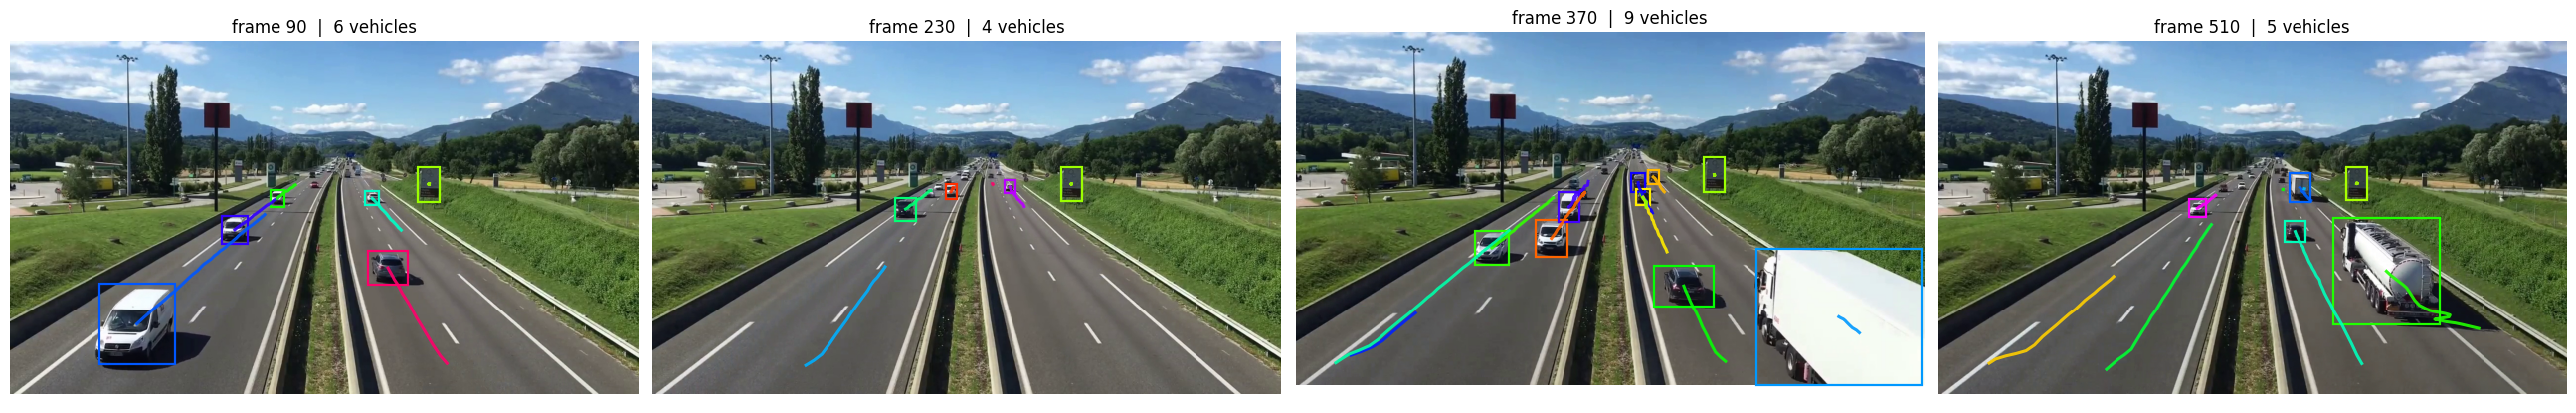

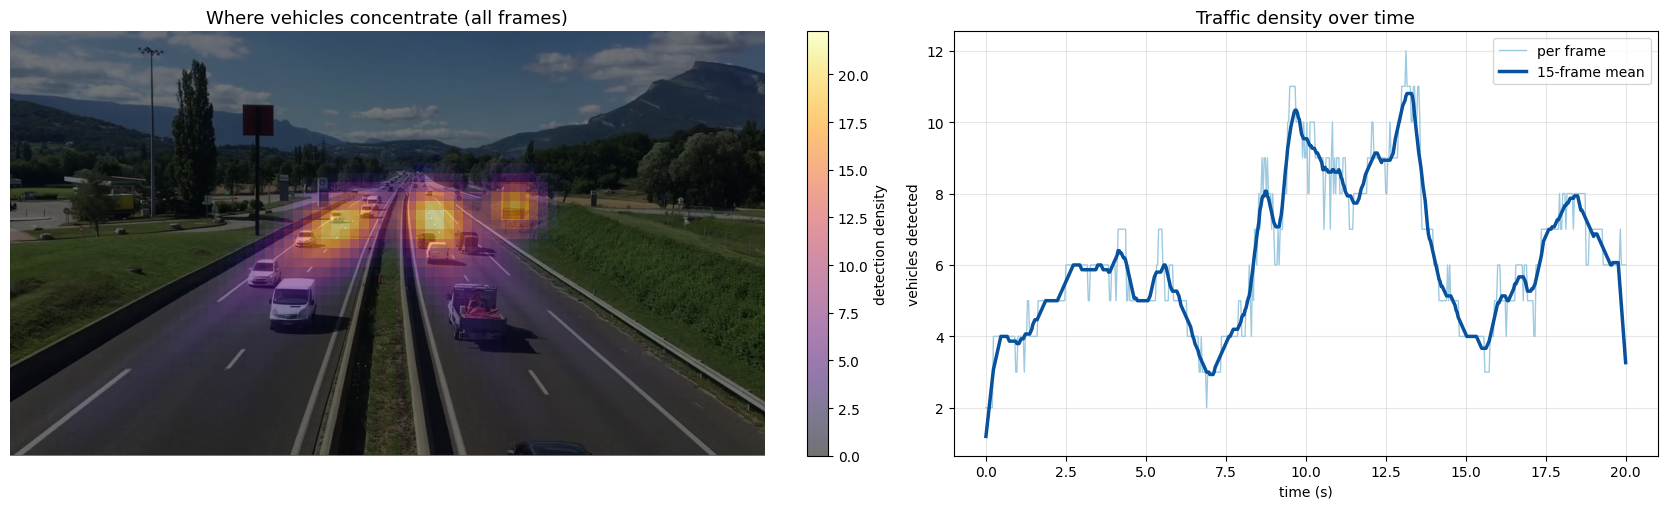

In [10]:
def track_stream(model, video):
    started = False
    try:
        for r in model.track(source=video, stream=True, persist=True, tracker='bytetrack.yaml', conf=CONF, imgsz=640, verbose=False, device=DEV):
            b = r.boxes; xyxy = b.xyxy.cpu().numpy()
            ids = b.id.int().cpu().numpy() if b.id is not None else np.full(len(xyxy), -1)
            started = True; yield r.orig_img, xyxy, ids
        return
    except Exception as e:
        if started: raise
        print('Built-in tracker unavailable (', type(e).__name__, ') -> using simple centroid tracker')
    nxt, prev = 0, {}
    for r in model.predict(source=video, stream=True, conf=CONF, imgsz=640, verbose=False, device=DEV):
        xyxy = r.boxes.xyxy.cpu().numpy(); cur = {}; ids = np.full(len(xyxy), -1); used = set()
        for j, b in enumerate(xyxy):
            c = np.array([(b[0] + b[2]) / 2, (b[1] + b[3]) / 2]); best, bd = None, 60.0
            for i, pc in prev.items():
                d = np.hypot(*(c - pc))
                if i not in used and d < bd: best, bd = i, d
            if best is None: best = nxt; nxt += 1
            used.add(best); ids[j] = best; cur[best] = c
        prev = cur; yield r.orig_img, xyxy, ids

VIDEO_STATS = None
if SAMPLE_VID:
    cap = cv2.VideoCapture(SAMPLE_VID); total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); fps = cap.get(cv2.CAP_PROP_FPS) or 25.0; cap.release()
    sel = set(np.linspace(int(total * 0.15), int(total * 0.85), 4).astype(int).tolist()); mid = total // 2
    hist, counts, centers, frames, boxes_at, bg = {}, [], [], {}, {}, None
    for f, (fr, xyxy, ids) in enumerate(track_stream(best_model, SAMPLE_VID)):
        counts.append(len(xyxy))
        for b, i in zip(xyxy, ids):
            cx, cy = (b[0] + b[2]) / 2, (b[1] + b[3]) / 2; centers.append((cx, cy))
            if i >= 0: hist.setdefault(int(i), []).append((f, cx, cy))
        if f in sel: frames[f] = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB); boxes_at[f] = (xyxy, ids)
        if f == mid: bg = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)
    VIDEO_STATS = dict(frames=len(counts), tracks=len(hist), mean_count=float(np.mean(counts)), max_count=int(np.max(counts)))
    print(f'Processed {len(counts)} frames | {len(hist)} tracks | mean {np.mean(counts):.1f} vehicles/frame, max {np.max(counts)}')
    fig_trails(frames, boxes_at, hist, os.path.join(FIG_DIR, 'fig3_motion_trails.png'))
    fig_density(bg if bg is not None else next(iter(frames.values())), centers, counts, fps, os.path.join(FIG_DIR, 'fig4_traffic_density.png'))
    PAPER['track'] = dict(frames=frames, boxes_at=boxes_at, hist=hist, bg=bg if bg is not None else next(iter(frames.values())), centers=centers, counts=counts, fps=fps)
else:
    print('sample_video.mp4 not found; skipping Fig 3 and Fig 4.')

# Part 3 | Study A: is the detector's count biased in dense scenes? (highway dataset)

**Hypothesis to test.** If the detector misses more vehicles as scenes get denser, raw box counts under-estimate traffic exactly when it is heaviest, and a bias-corrected count would have a real problem to solve.

**Measure.** For each validation image we compare true vs detected counts, and for each individual vehicle we record whether it was found ("hit") together with its size, overlap and neighbour count.

### 3.1 Tables and threshold sensitivity
`build_tables_A` produces (a) a per-image table with true count, predicted count, true positives, false positives, misses; and (b) a per-vehicle table with hit/miss and covariates. The printed table shows how recall, precision and net count bias change with the confidence threshold. **Net count bias mixes misses and false positives** (they cancel), so recall is the number to model.

In [11]:
def build_tables_A(conf):
    rows_img, rows_obj = [], []
    for name, gt, (pb, pc) in zip(val_names, gts, val_det):
        keep = pc >= conf; hit = match_greedy(gt, pb[keep], pc[keep])
        tp = int(hit.sum()); pred_n = int(keep.sum()); gt_n = len(gt)
        rows_img.append(dict(image=name, gt_n=gt_n, pred_n=pred_n, tp=tp, fp=pred_n - tp, fn=gt_n - tp))
        f = gt_features(gt); f['hit'] = hit.astype(int); f['image'] = name; f['gt_n'] = gt_n; rows_obj.append(f)
    return pd.DataFrame(rows_img), pd.concat(rows_obj, ignore_index=True)

img_df, obj_df = build_tables_A(CONF)
sensA = []
for c in [0.25, 0.4, 0.5, 0.6]:
    d, _ = build_tables_A(c); G_, P_, T_ = d.gt_n.sum(), d.pred_n.sum(), d.tp.sum()
    sensA.append(dict(conf=c, GT=G_, predicted=P_, matched=T_, recall=T_ / G_, precision=T_ / max(P_, 1), net_count_bias_pct=100 * (P_ - G_) / G_))
sensA = pd.DataFrame(sensA); print(sensA.round(3).to_string(index=False))
img_df.to_csv('studyA_per_image.csv', index=False); obj_df.to_csv('studyA_per_vehicle.csv', index=False); sensA.to_csv('studyA_sensitivity.csv', index=False)

 conf  GT  predicted  matched  recall  precision  net_count_bias_pct
 0.25 937       1109      911   0.972      0.821              18.356
 0.40 937       1038      894   0.954      0.861              10.779
 0.50 937        985      880   0.939      0.893               5.123
 0.60 937        937      855   0.912      0.912               0.000


### 3.2 Diagnostic figure (six panels)
Top row: detected vs true count; signed count error vs density; the range of densities in this dataset. Bottom row: **recall vs image density, vehicle size, and overlap**, each with 95% Wilson intervals. A flat "recall vs image density" curve means density does not cause misses in this data.

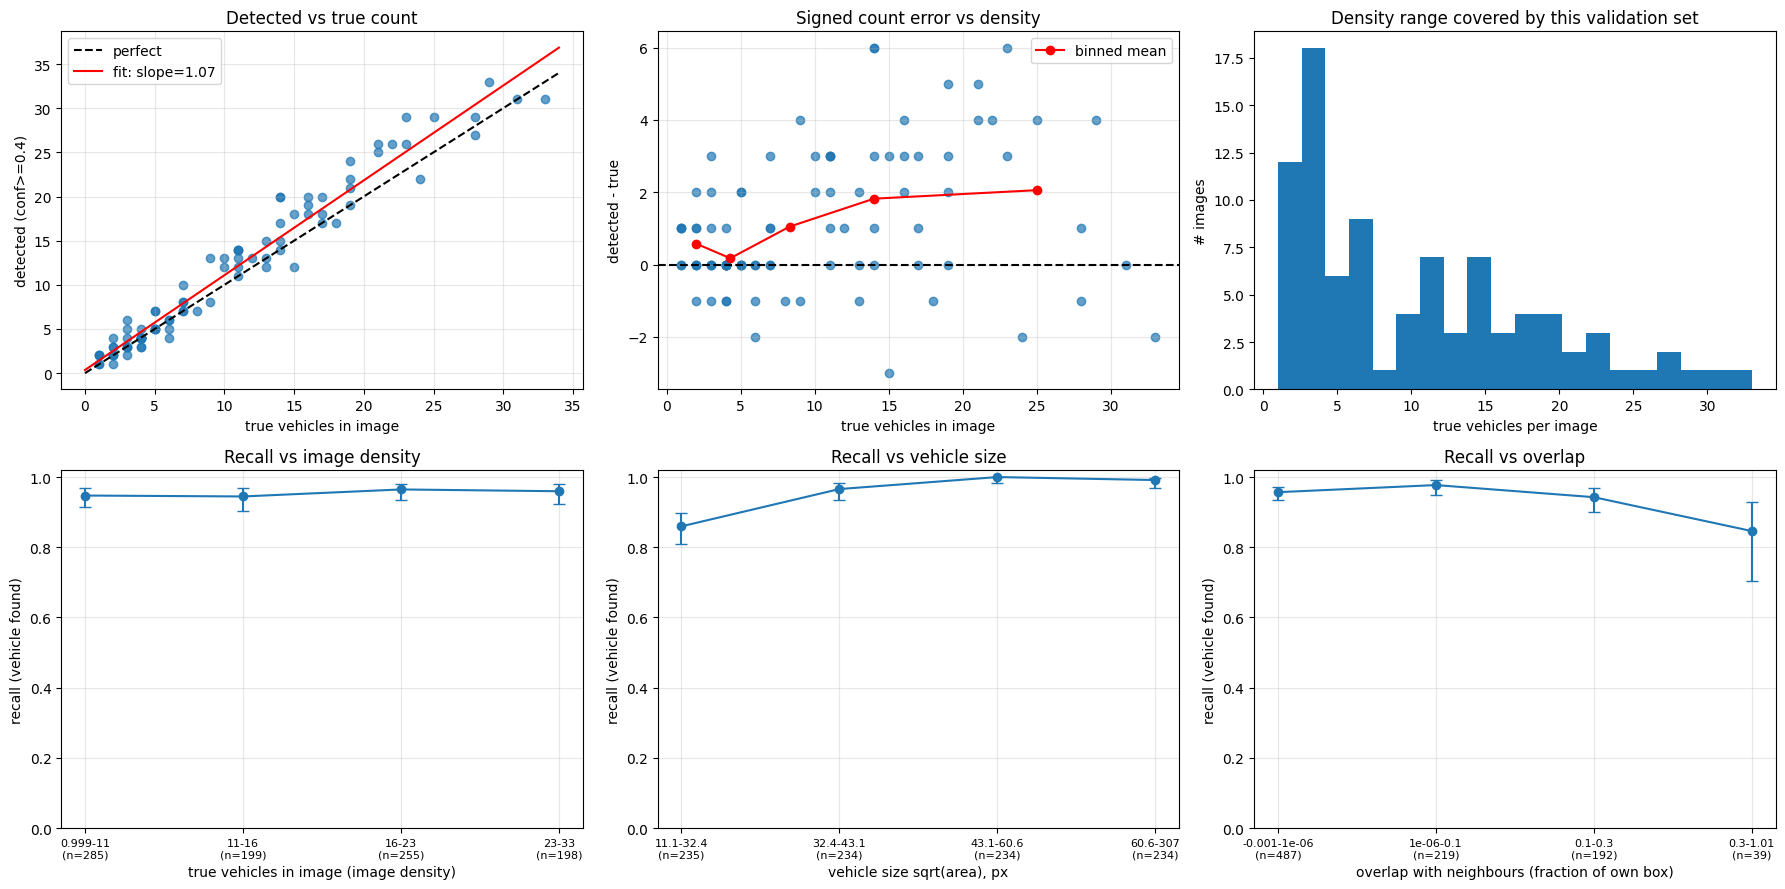

In [12]:
def recall_by_bin(ax, x, hit, xlabel, q=4, edges=None):
    df = pd.DataFrame({'x': x, 'hit': hit})
    df['bin'] = pd.cut(df.x, edges, include_lowest=True) if edges is not None else pd.qcut(df.x, q, duplicates='drop')
    g = df.groupby('bin', observed=True).hit.agg(['sum', 'count']); rec = g['sum'] / g['count']
    ci = np.array([wilson(k, n) for k, n in zip(g['sum'], g['count'])]); xs = np.arange(len(g))
    ax.errorbar(xs, rec, yerr=[rec - ci[:, 0], ci[:, 1] - rec], fmt='o-', capsize=4)
    ax.set_xticks(xs); ax.set_xticklabels([f'{b.left:.3g}-{b.right:.3g}\n(n={n})' for b, n in zip(g.index, g['count'])], fontsize=8)
    ax.set_ylim(0, 1.02); ax.set_ylabel('recall (vehicle found)'); ax.set_xlabel(xlabel); ax.grid(alpha=.3)

fig, ax = plt.subplots(2, 3, figsize=(18, 9))
a = ax[0, 0]; a.scatter(img_df.gt_n, img_df.pred_n, alpha=.7); m = max(img_df.gt_n.max(), img_df.pred_n.max()) + 1; a.plot([0, m], [0, m], 'k--', label='perfect')
if img_df.gt_n.nunique() > 1: s, b = np.polyfit(img_df.gt_n, img_df.pred_n, 1); a.plot([0, m], [b, s*m + b], 'r-', label=f'fit: slope={s:.2f}')
a.set_xlabel('true vehicles in image'); a.set_ylabel(f'detected (conf>={CONF})'); a.legend(); a.set_title('Detected vs true count'); a.grid(alpha=.3)
a = ax[0, 1]; err = img_df.pred_n - img_df.gt_n; a.scatter(img_df.gt_n, err, alpha=.7); a.axhline(0, color='k', ls='--')
bb = pd.qcut(img_df.gt_n, 5, duplicates='drop'); mm = err.groupby(bb, observed=True).mean(); a.plot([i.mid for i in mm.index], mm.values, 'r-o', label='binned mean')
a.set_xlabel('true vehicles in image'); a.set_ylabel('detected - true'); a.legend(); a.set_title('Signed count error vs density'); a.grid(alpha=.3)
a = ax[0, 2]; a.hist(img_df.gt_n, bins=20); a.set_xlabel('true vehicles per image'); a.set_ylabel('# images'); a.set_title('Density range covered by this validation set')
recall_by_bin(ax[1, 0], obj_df.gt_n, obj_df.hit, 'true vehicles in image (image density)'); ax[1, 0].set_title('Recall vs image density')
recall_by_bin(ax[1, 1], obj_df['size'], obj_df.hit, 'vehicle size sqrt(area), px'); ax[1, 1].set_title('Recall vs vehicle size')
recall_by_bin(ax[1, 2], obj_df.occl, obj_df.hit, 'overlap with neighbours (fraction of own box)', edges=[0, 1e-6, 0.1, 0.3, 1.01]); ax[1, 2].set_title('Recall vs overlap')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'studyA_diagnostics.png'), dpi=150); plt.show()

### 3.3 Which factors make a vehicle get missed? (logistic regression)
We model P(vehicle found) as a function of **log size, neighbour count and overlap**, standardised so each odds ratio is "per +1 standard deviation". Standard errors are **clustered by image** because vehicles in the same image are not independent. An odds ratio below 1 with a confidence interval excluding 1 means recall falls as that factor rises.

In [13]:
import statsmodels.api as sm
d = obj_df.dropna().copy(); d['log_size'] = np.log(d['size'].clip(lower=1))
X = d[['log_size', 'nbrs', 'occl']].astype(float); X = (X - X.mean()) / (X.std() + 1e-9); X = sm.add_constant(X)
try:
    fit = sm.Logit(d['hit'], X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': pd.factorize(d['image'])[0]})
    outA = pd.DataFrame({'odds_ratio': np.exp(fit.params), 'OR_lo95': np.exp(fit.conf_int()[0]), 'OR_hi95': np.exp(fit.conf_int()[1]), 'p': fit.pvalues}).round(3)
    print(outA.to_string()); outA.to_csv('studyA_logistic.csv')
except Exception as e:
    print('Logistic fit failed (too few misses or perfect separation):', e)

          odds_ratio  OR_lo95  OR_hi95      p
const         62.813   36.252  108.833  0.000
log_size       5.565    3.654    8.476  0.000
nbrs           0.999    0.551    1.811  0.998
occl           0.548    0.433    0.694  0.000


### 3.4 Study A verdict (bootstrap over images)
Images are split into the **sparsest third** and the **densest third** by true vehicle count. We compare recall in the two groups and compute a 95% **bootstrap** confidence interval for the difference by resampling *whole images* (not vehicles) 2,000 times. The premise is supported only if the interval for "recall drop (low - high)" is entirely above zero.

**Caveat:** 90 correlated images, and `best.pt` was selected on this same split. Treat this as a go/no-go signal, not paper-grade evidence.

In [14]:
rng = np.random.default_rng(0)
gt_n, tp, pr = img_df.gt_n.values, img_df.tp.values, img_df.pred_n.values
q_lo, q_hi = np.quantile(gt_n, [1/3, 2/3]); lo_mask, hi_mask = gt_n <= q_lo, gt_n >= q_hi
print(f'Low-density images : <= {q_lo:.0f} vehicles (n={lo_mask.sum()}) | High-density images: >= {q_hi:.0f} vehicles (n={hi_mask.sum()})')
def statsA(idx):
    lo, hi = idx[lo_mask[idx]], idx[hi_mask[idx]]
    rl = tp[lo].sum() / max(gt_n[lo].sum(), 1); rh = tp[hi].sum() / max(gt_n[hi].sum(), 1)
    bl = (pr[lo].sum() - gt_n[lo].sum()) / max(gt_n[lo].sum(), 1); bh = (pr[hi].sum() - gt_n[hi].sum()) / max(gt_n[hi].sum(), 1)
    return rl, rh, rl - rh, bl, bh
ptA = statsA(np.arange(len(gt_n))); bootA = np.array([statsA(rng.integers(0, len(gt_n), len(gt_n))) for _ in range(2000)])
ciA = np.nanpercentile(bootA, [2.5, 97.5], axis=0)
resA = pd.DataFrame({'estimate': ptA, 'CI_2.5': ciA[0], 'CI_97.5': ciA[1]},
                    index=['recall (low density)', 'recall (high density)', 'recall drop (low - high)', 'net count bias (low)', 'net count bias (high)']).round(3)
print(); print(resA.to_string()); resA.to_csv('studyA_verdict.csv')
A_SUPPORTED = bool(ciA[0][2] > 0)
print('\nSTUDY A VERDICT:', 'premise SUPPORTED on this data' if A_SUPPORTED else 'premise NOT supported on this data (recall drop not distinguishable from 0)')

Low-density images : <= 5 vehicles (n=30) | High-density images: >= 13 vehicles (n=30)

                          estimate  CI_2.5  CI_97.5
recall (low density)         0.929   0.873    0.974
recall (high density)        0.960   0.938    0.980
recall drop (low - high)    -0.031  -0.089    0.019
net count bias (low)         0.119   0.000    0.254
net count bias (high)        0.106   0.061    0.155

STUDY A VERDICT: premise NOT supported on this data (recall drop not distinguishable from 0)


# Part 4 | Study B: the same question on a much denser benchmark (VisDrone)

Study A used an easy dataset (median 7, max 33 vehicles per image, top-down views with little occlusion), so it cannot rule out a density effect in crowded scenes. Study B uses **VisDrone2019-DET validation (548 drone images)** with hundreds of vehicles in some scenes and **human-annotated occlusion levels**, and **off-the-shelf COCO-pretrained YOLOv8 n/s/m** (no training).

**Pre-registered decision rule (fixed before seeing results).** The premise is SUPPORTED only if, for **every** detector, recall in the densest third of images is significantly lower than in the sparsest third **and this still holds when only vehicles >= 32 px are counted** (so it is not merely the known "small objects are hard" effect). Otherwise we do **not** build the paper on this claim.

Vehicles = VisDrone car/van/truck/bus vs COCO car/bus/truck (class-agnostic matching, IoU >= 0.5). Detections inside VisDrone's official *ignored regions* are discarded.

### 4.1 Download and parse VisDrone (validation split only)
Downloads the small validation zip and parses each annotation row (`left, top, width, height, score, category, truncation, occlusion`). Rows with score 0 are ignore-regions; vehicle categories are kept with their occlusion label (0 none, 1 partial, 2 heavy).

In [15]:
VEH_CATS = {4: 'car', 5: 'van', 6: 'truck', 9: 'bus'}; COCO_VEH = [2, 5, 7]
VAL_URL = 'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip'
vpath = os.path.join(WORK, 'VisDrone2019-DET-val.zip')
if not os.path.exists(vpath):
    try: urllib.request.urlretrieve(VAL_URL, vpath)
    except Exception as e:
        print('urllib failed (', type(e).__name__, ') -> trying wget'); subprocess.run(['wget', '-q', '-O', vpath, VAL_URL], check=True)
vd_dir = os.path.join(WORK, 'visdrone'); os.makedirs(vd_dir, exist_ok=True)
with zipfile.ZipFile(vpath) as z: z.extractall(vd_dir)
vd_root = next((dp for dp, dn, fn in os.walk(vd_dir) if 'train' not in os.path.basename(dp).lower() and os.path.isdir(os.path.join(dp, 'annotations')) and os.path.isdir(os.path.join(dp, 'images'))), None)
assert vd_root, 'Could not find VisDrone val folders after extraction.'
img_paths_vd = sorted(glob.glob(f'{vd_root}/images/*.jpg'))

def parse_ann(path):
    veh, occ, ign = [], [], []
    if os.path.exists(path):
        for line in open(path):
            p = line.strip().split(',')
            if len(p) < 8: continue
            x, y, w, h, score, cat, tr, oc = [int(float(v)) for v in p[:8]]; box = [x, y, x + w, y + h]
            if score == 0 or cat == 0: ign.append(box)
            elif cat in VEH_CATS: veh.append(box); occ.append(oc)
    return np.array(veh, float).reshape(-1, 4), np.array(occ, float), np.array(ign, float).reshape(-1, 4)

names_vd, gt_vd, occ_vd, ign_vd = [], [], [], []
for p in img_paths_vd:
    g, o, ig = parse_ann(os.path.join(vd_root, 'annotations', os.path.basename(p).replace('.jpg', '.txt')))
    names_vd.append(os.path.basename(p)); gt_vd.append(g); occ_vd.append(o); ign_vd.append(ig)
cnt_vd = np.array([len(g) for g in gt_vd])
print(f'{len(img_paths_vd)} images | vehicles per image: min {cnt_vd.min()}, median {int(np.median(cnt_vd))}, 90th pct {int(np.percentile(cnt_vd, 90))}, max {cnt_vd.max()}, total {cnt_vd.sum()}')
allocc = np.concatenate([o for o in occ_vd if len(o)]); print('Occlusion labels (0 none / 1 partial / 2 heavy):', {int(k): int(v) for k, v in zip(*np.unique(allocc, return_counts=True))})

548 images | vehicles per image: min 0, median 27, 90th pct 61, max 153, total 17040
Occlusion labels (0 none / 1 partial / 2 heavy): {0: 8024, 1: 7557, 2: 1459}


### 4.2 Run the three off-the-shelf detectors
Each COCO-pretrained model (nano, small, medium) is run at 1280 px, restricted to the COCO vehicle classes, with a low confidence floor. Detections whose centre lies inside an ignored region are dropped. Using several detector sizes checks that any finding is not specific to one network.

In [16]:
def in_ignore(pb, ign):
    if len(pb) == 0 or len(ign) == 0: return np.zeros(len(pb), dtype=bool)
    cx = (pb[:, 0] + pb[:, 2]) / 2; cy = (pb[:, 1] + pb[:, 3]) / 2
    return ((cx[:, None] >= ign[None, :, 0]) & (cx[:, None] <= ign[None, :, 2]) & (cy[:, None] >= ign[None, :, 1]) & (cy[:, None] <= ign[None, :, 3])).any(1)

DET_vd = {}
for mname in MODELS_VD:
    mdl = YOLO(mname); out = []
    for i in range(0, len(img_paths_vd), 8):
        for k, r in enumerate(mdl.predict(source=img_paths_vd[i:i+8], imgsz=IMGSZ_VD, conf=0.05, classes=COCO_VEH, max_det=1000, verbose=False, device=DEV)):
            pb = r.boxes.xyxy.cpu().numpy(); pc = r.boxes.conf.cpu().numpy(); drop = in_ignore(pb, ign_vd[i + k]); out.append((pb[~drop], pc[~drop]))
    DET_vd[mname] = out; print(f'{mname}: detections computed for {len(out)} images')

yolov8n.pt: detections computed for 548 images
yolov8s.pt: detections computed for 548 images
yolov8m.pt: detections computed for 548 images


### 4.3 Tables, threshold sensitivity and the verdict function
`build_tables_vd` mirrors Study A but also carries VisDrone's **annotated occlusion** label. `verdict_vd` compares recall in the sparsest vs densest third of images (by true count; images with no vehicles excluded), with a bootstrap over images, optionally restricted to vehicles >= `size_min` px.

In [17]:
def build_tables_vd(mname, conf):
    rows_img, rows_obj = [], []
    for name, gt, occ, (pb, pc) in zip(names_vd, gt_vd, occ_vd, DET_vd[mname]):
        keep = pc >= conf; hit = match_greedy(gt, pb[keep], pc[keep])
        tp = int(hit.sum()); pred_n = int(keep.sum()); gt_n = len(gt)
        rows_img.append(dict(image=name, gt_n=gt_n, pred_n=pred_n, tp=tp, fp=pred_n - tp, fn=gt_n - tp))
        if gt_n:
            f = gt_features(gt); f['occ'] = occ.ravel(); f['hit'] = hit.astype(int); f['image'] = name; f['gt_n'] = gt_n; rows_obj.append(f)
    return pd.DataFrame(rows_img), pd.concat(rows_obj, ignore_index=True)

def verdict_vd(di, do, size_min=0, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed); dd = do[do['size'] >= size_min]
    per = dd.groupby('image').hit.agg(tp='sum', n='count').reindex(di.image).fillna(0); valid = (di.gt_n.values > 0)
    gt_all = di.gt_n.values[valid]; tp_ = per.tp.values[valid]; n_ = per.n.values[valid]
    ql, qh = np.quantile(gt_all, [1/3, 2/3]); lo_m, hi_m = gt_all <= ql, gt_all >= qh
    def stat(idx):
        lo, hi = idx[lo_m[idx]], idx[hi_m[idx]]
        rl = tp_[lo].sum() / max(n_[lo].sum(), 1); rh = tp_[hi].sum() / max(n_[hi].sum(), 1); return rl, rh, rl - rh
    pt = stat(np.arange(len(gt_all))); bt = np.array([stat(rng.integers(0, len(gt_all), len(gt_all))) for _ in range(n_boot)]); ci = np.nanpercentile(bt, [2.5, 97.5], axis=0)
    return dict(q_lo=ql, q_hi=qh, n_lo=int(lo_m.sum()), n_hi=int(hi_m.sum()), recall_low=pt[0], recall_high=pt[1], drop=pt[2], drop_lo=ci[0][2], drop_hi=ci[1][2])

TABLES_vd = {m: build_tables_vd(m, CONF_VD) for m in MODELS_VD}
rows = []
for m in MODELS_VD:
    for c in [0.25, 0.4, 0.5]:
        d, _ = build_tables_vd(m, c); G_, P_, T_ = d.gt_n.sum(), d.pred_n.sum(), d.tp.sum()
        rows.append(dict(model=m, conf=c, GT=G_, predicted=P_, matched=T_, recall=T_ / G_, precision=T_ / max(P_, 1), net_count_bias_pct=100 * (P_ - G_) / G_))
sensB = pd.DataFrame(rows); print(sensB.round(3).to_string(index=False)); sensB.to_csv('studyB_sensitivity.csv', index=False)

     model  conf    GT  predicted  matched  recall  precision  net_count_bias_pct
yolov8n.pt  0.25 17040      10139     8051   0.472      0.794             -40.499
yolov8n.pt  0.40 17040       6954     6295   0.369      0.905             -59.190
yolov8n.pt  0.50 17040       5376     5060   0.297      0.941             -68.451
yolov8s.pt  0.25 17040      11607     9520   0.559      0.820             -31.884
yolov8s.pt  0.40 17040       8947     8066   0.473      0.902             -47.494
yolov8s.pt  0.50 17040       7518     7015   0.412      0.933             -55.880
yolov8m.pt  0.25 17040      11272     9513   0.558      0.844             -33.850
yolov8m.pt  0.40 17040       9105     8258   0.485      0.907             -46.567
yolov8m.pt  0.50 17040       7865     7343   0.431      0.934             -53.844


### 4.4 Study B diagnostic figure
Top row: **recall vs image density** for all vehicles, for vehicles >= 32 px only, and recall vs vehicle size (one curve per detector, shaded = 95% Wilson interval; log x-axis). Bottom row: recall by **annotated occlusion level**, detected vs true counts, and the density range. If the curves fall as density rises, the premise has support. If they are flat once small vehicles are excluded, the effect is only the known small-object problem.

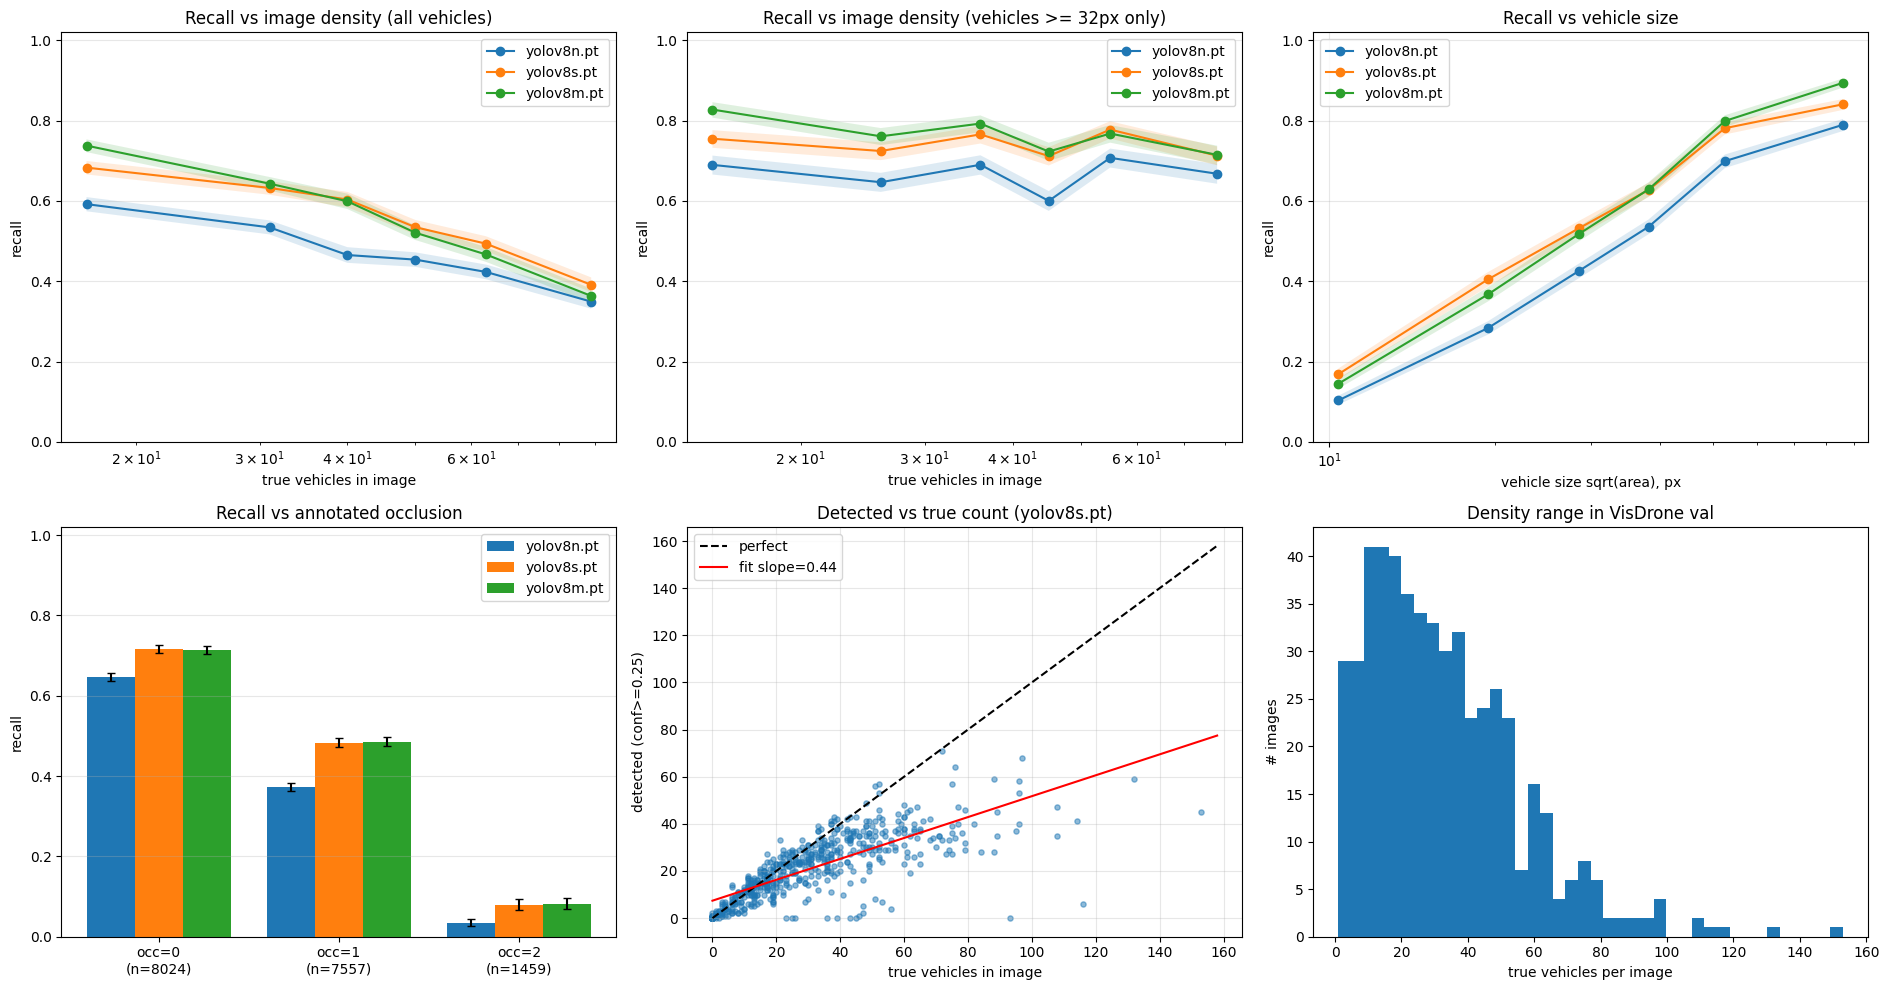

In [18]:
def curve(ax, x, hit, label, q=6):
    df = pd.DataFrame({'x': np.asarray(x, float), 'hit': np.asarray(hit)}); df['bin'] = pd.qcut(df.x, q, duplicates='drop')
    g = df.groupby('bin', observed=True).agg(xm=('x', 'median'), k=('hit', 'sum'), n=('hit', 'count')); rec = g.k / g.n
    ci = np.array([wilson(k, n) for k, n in zip(g.k, g.n)]); ax.plot(g.xm, rec, 'o-', label=label); ax.fill_between(g.xm, ci[:, 0], ci[:, 1], alpha=.15)

fig, ax = plt.subplots(2, 3, figsize=(19, 10))
for m in MODELS_VD:
    _, o = TABLES_vd[m]; big = o[o['size'] >= SIZE_MIN]
    curve(ax[0, 0], o.gt_n, o.hit, m); curve(ax[0, 1], big.gt_n, big.hit, m); curve(ax[0, 2], o['size'], o.hit, m)
ax[0, 0].set_title('Recall vs image density (all vehicles)'); ax[0, 1].set_title(f'Recall vs image density (vehicles >= {SIZE_MIN}px only)'); ax[0, 2].set_title('Recall vs vehicle size')
for a_, xl in zip(ax[0], ['true vehicles in image', 'true vehicles in image', 'vehicle size sqrt(area), px']):
    a_.set_xlabel(xl); a_.set_xscale('log'); a_.set_ylabel('recall'); a_.set_ylim(0, 1.02); a_.grid(alpha=.3); a_.legend()
a_ = ax[1, 0]; w_ = 0.8 / len(MODELS_VD)
for i, m in enumerate(MODELS_VD):
    _, o = TABLES_vd[m]; g = o.groupby('occ').hit.agg(['sum', 'count']); rec = g['sum'] / g['count']; ci = np.array([wilson(k, n) for k, n in zip(g['sum'], g['count'])])
    a_.bar(np.arange(len(g)) + i * w_, rec, w_, yerr=[rec - ci[:, 0], ci[:, 1] - rec], capsize=3, label=m)
a_.set_xticks(np.arange(len(g)) + 0.4 - w_ / 2); a_.set_xticklabels([f'occ={int(k)}\n(n={n})' for k, n in zip(g.index, g['count'])])
a_.set_title('Recall vs annotated occlusion'); a_.set_ylabel('recall'); a_.set_ylim(0, 1.02); a_.legend(); a_.grid(alpha=.3, axis='y')
m0 = MODELS_VD[len(MODELS_VD) // 2]; d0, _ = TABLES_vd[m0]; a_ = ax[1, 1]; a_.scatter(d0.gt_n, d0.pred_n, alpha=.5, s=14); mx = max(d0.gt_n.max(), d0.pred_n.max()) + 5
a_.plot([0, mx], [0, mx], 'k--', label='perfect')
if d0.gt_n.nunique() > 1: s, b = np.polyfit(d0.gt_n, d0.pred_n, 1); a_.plot([0, mx], [b, s*mx + b], 'r-', label=f'fit slope={s:.2f}')
a_.set_title(f'Detected vs true count ({m0})'); a_.set_xlabel('true vehicles in image'); a_.set_ylabel(f'detected (conf>={CONF_VD})'); a_.legend(); a_.grid(alpha=.3)
a_ = ax[1, 2]; a_.hist(d0.gt_n[d0.gt_n > 0], bins=40); a_.set_xlabel('true vehicles per image'); a_.set_ylabel('# images'); a_.set_title('Density range in VisDrone val')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'studyB_diagnostics.png'), dpi=150); plt.show()

### 4.5 Study B logistic regression per detector
Same idea as 3.3 but with **annotated occlusion** and **image density** as separate predictors, alongside size and neighbour count. **The key row is `log_density`**: if its odds ratio is close to 1, image density has no effect once vehicle size and occlusion are accounted for.

In [19]:
for m in MODELS_VD:
    _, o = TABLES_vd[m]; d = o.dropna().copy(); d['log_size'] = np.log(d['size'].clip(lower=1)); d['log_density'] = np.log(d['gt_n'])
    X = d[['log_size', 'nbrs', 'occ', 'log_density']].astype(float); X = (X - X.mean()) / (X.std() + 1e-9); X = sm.add_constant(X)
    try:
        fit = sm.Logit(d['hit'], X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': pd.factorize(d['image'])[0]})
        out = pd.DataFrame({'odds_ratio': np.exp(fit.params), 'OR_lo95': np.exp(fit.conf_int()[0]), 'OR_hi95': np.exp(fit.conf_int()[1]), 'p': fit.pvalues}).round(3)
        print(f'--- {m} ---'); print(out.to_string()); print(); out.to_csv(f'studyB_logistic_{m.replace(".pt", "")}.csv')
    except Exception as e:
        print(m, 'logistic fit failed:', e)

--- yolov8n.pt ---
             odds_ratio  OR_lo95  OR_hi95      p
const             0.841    0.755    0.937  0.002
log_size          3.855    3.358    4.426  0.000
nbrs              0.900    0.830    0.975  0.010
occ               0.375    0.337    0.417  0.000
log_density       1.019    0.868    1.196  0.821

--- yolov8s.pt ---
             odds_ratio  OR_lo95  OR_hi95      p
const             1.430    1.253    1.633  0.000
log_size          3.557    3.054    4.142  0.000
nbrs              0.975    0.887    1.072  0.606
occ               0.387    0.344    0.436  0.000
log_density       0.880    0.744    1.041  0.135

--- yolov8m.pt ---
             odds_ratio  OR_lo95  OR_hi95      p
const             1.486    1.281    1.724  0.000
log_size          4.643    3.889    5.544  0.000
nbrs              0.895    0.814    0.984  0.022
occ               0.374    0.327    0.428  0.000
log_density       0.762    0.643    0.904  0.002



### 4.6 Study B final verdict (pre-registered rule)
For each detector and for two subsets (all vehicles; vehicles >= 32 px), the table reports recall in the sparsest third, recall in the densest third, and the drop with its 95% bootstrap CI (`drop_lo` > 0 means significant). The printed decision applies the rule stated above, with no post-hoc adjustment.

In [20]:
rows = []
for m in MODELS_VD:
    di, do = TABLES_vd[m]
    for tag, smin in [('all vehicles', 0), (f'>= {SIZE_MIN}px only', SIZE_MIN)]:
        v = verdict_vd(di, do, size_min=smin); v.update(model=m, subset=tag); rows.append(v)
R = pd.DataFrame(rows)[['model', 'subset', 'n_lo', 'q_lo', 'n_hi', 'q_hi', 'recall_low', 'recall_high', 'drop', 'drop_lo', 'drop_hi']]
print(R.round(3).to_string(index=False)); R.to_csv('studyB_verdict.csv', index=False)
B_SIG_ALL  = all(R[(R.model == m) & (R.subset == 'all vehicles')].drop_lo.iloc[0] > 0 for m in MODELS_VD)
B_SIG_SIZE = all(R[(R.model == m) & (R.subset != 'all vehicles')].drop_lo.iloc[0] > 0 for m in MODELS_VD)
print('\nSTUDY B VERDICT (pre-registered rule):')
if B_SIG_ALL and B_SIG_SIZE:   print('SUPPORTED: recall is significantly lower in dense images for every detector, even for vehicles >= %dpx.' % SIZE_MIN)
elif B_SIG_ALL:                print('PARTIAL: the drop appears for all vehicles but NOT for larger vehicles -> mostly the known small-object effect.')
else:                          print('NOT SUPPORTED: no significant recall drop in dense images for every detector.')

     model       subset  n_lo  q_lo  n_hi  q_hi  recall_low  recall_high  drop  drop_lo  drop_hi
yolov8n.pt all vehicles   180  19.0   174  39.0       0.591        0.416 0.175    0.128    0.221
yolov8n.pt >= 32px only   180  19.0   174  39.0       0.693        0.656 0.037   -0.021    0.099
yolov8s.pt all vehicles   180  19.0   174  39.0       0.683        0.493 0.190    0.144    0.234
yolov8s.pt >= 32px only   180  19.0   174  39.0       0.763        0.732 0.031   -0.029    0.094
yolov8m.pt all vehicles   180  19.0   174  39.0       0.742        0.472 0.270    0.226    0.313
yolov8m.pt >= 32px only   180  19.0   174  39.0       0.833        0.734 0.100    0.041    0.161

STUDY B VERDICT (pre-registered rule):
PARTIAL: the drop appears for all vehicles but NOT for larger vehicles -> mostly the known small-object effect.


### 2.5 Paper-ready Figure 1: all four qualitative figures merged into one
Page space is limited (CVPR allows 8 pages), so the four separate figures above are **merged into a single full-width figure** with panel letters: **(a)** a sparse and **(b)** a dense validation image (green = ground truth found, blue = correct detection, **red = missed vehicle**, orange dashed = false positive; images chosen by vehicle count only), **(c)** COCO-pretrained vs **(d)** fine-tuned detections on the sample image, **(e)** vehicle tracks (ByteTrack) on a video frame, **(f)** a heat-map of where vehicles concentrate over the video, and **(g)** vehicles per frame over time (the real-time density estimate). Saved as vector **PDF** (for LaTeX) and 300-dpi **PNG** in `paper_assets/`. Width is 6.9 in, the full text width of a CVPR two-column page (use `figure*`).

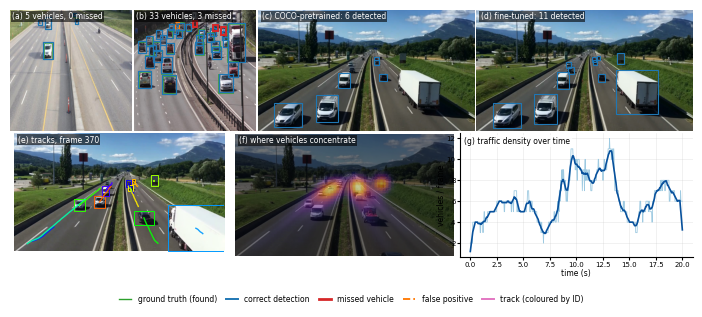

Saved paper_assets/fig1_qualitative.pdf and .png


In [21]:
PAPER_DIR = os.path.abspath('paper_assets'); os.makedirs(PAPER_DIR, exist_ok=True)
from scipy.ndimage import gaussian_filter

def _ar(im): return im.shape[1] / im.shape[0]

def paper_fig1(P, base, W=6.9):
    tx = dict(fontsize=5.5, color='white', va='top', ha='left', zorder=5, bbox=dict(boxstyle='square,pad=0.15', fc='black', ec='none', alpha=.6))
    g = P['gallery']; sp, de = g[1], g[-1]
    ims1 = [sp['img'], de['img'], P['pre']['img'], P['ft']['img']]; ars1 = [_ar(i) for i in ims1]
    tr = P['track']; fmid = sorted(tr['frames'])[len(tr['frames']) // 2]; fr = tr['frames'][fmid]; ars2 = [_ar(fr), _ar(fr), 1.9]
    Wc = W * 0.99; H1 = Wc / sum(ars1); H2 = (Wc / sum(ars2)) / 0.80; HL = 0.22
    fig = plt.figure(figsize=(W, H1 + H2 + HL)); sf = fig.subfigures(3, 1, height_ratios=[H1, H2, HL], hspace=0.0)
    kw1 = dict(width_ratios=ars1, wspace=0.01, left=0.005, right=0.995, top=0.995, bottom=0.005)
    a1 = sf[0].subplots(1, 4, gridspec_kw=kw1)
    for ax, it, lab in zip(a1[:2], (sp, de), 'ab'):
        keep = it['pc'] >= CONF; pb = it['pb'][keep]; pc = it['pc'][keep]; hit, ok = match2(it['gt'], pb, pc)
        ax.imshow(it['img']); ax.axis('off')
        add_boxes(ax, it['gt'][hit], C_GT, 0.5); add_boxes(ax, pb[ok], C_TP, 0.9); add_boxes(ax, it['gt'][~hit], C_MISS, 1.4); add_boxes(ax, pb[~ok], C_FP, 0.9, '--')
        ax.text(0.02, 0.98, f"({lab}) {len(it['gt'])} vehicles, {int((~hit).sum())} missed", transform=ax.transAxes, **tx)
    for ax, key, lab, name in zip(a1[2:], ('pre', 'ft'), 'cd', ('COCO-pretrained', 'fine-tuned')):
        ax.imshow(P[key]['img']); ax.axis('off'); add_boxes(ax, P[key]['boxes'], C_TP, 0.8)
        ax.text(0.02, 0.98, f"({lab}) {name}: {len(P[key]['boxes'])} detected", transform=ax.transAxes, **tx)
    kw2 = dict(width_ratios=ars2, wspace=0.03, left=0.005, right=0.995, top=0.995, bottom=0.20)
    a2 = sf[1].subplots(1, 3, gridspec_kw=kw2)
    ax = a2[0]; ax.imshow(fr); ax.axis('off'); xyxy, ids = tr['boxes_at'][fmid]
    for b, i in zip(xyxy, ids): ax.add_patch(Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec=id_color(int(i)) if i >= 0 else 'w', lw=0.7))
    for i, pts in tr['hist'].items():
        seg = np.array([(cx, cy) for (ff, cx, cy) in pts if fmid - 45 <= ff <= fmid])
        if len(seg) >= 2: ax.plot(seg[:, 0], seg[:, 1], '-', color=id_color(i), lw=1.0, alpha=.9)
    ax.text(0.02, 0.98, f'(e) tracks, frame {fmid}', transform=ax.transAxes, **tx)
    ax = a2[1]; bg = tr['bg']; Hh, Wd = bg.shape[:2]; cx, cy = np.array(tr['centers']).T
    Hm, _, _ = np.histogram2d(cx, cy, bins=[max(Wd // 16, 8), max(Hh // 16, 8)], range=[[0, Wd], [0, Hh]]); Hm = gaussian_filter(Hm.T, 2)
    ax.imshow(bg); ax.imshow(Hm, extent=[0, Wd, Hh, 0], cmap='inferno', alpha=.55); ax.axis('off'); ax.text(0.02, 0.98, '(f) where vehicles concentrate', transform=ax.transAxes, **tx)
    ax = a2[2]; c = np.array(tr['counts'], float); t = np.arange(len(c)) / tr['fps']; w = min(15, max(len(c) // 5, 1))
    ax.plot(t, c, color='#9ecae1', lw=0.6); ax.plot(t, np.convolve(c, np.ones(w) / w, mode='same'), color='#08519c', lw=1.2)
    ax.set_xlabel('time (s)', fontsize=5.5, labelpad=1); ax.set_ylabel('vehicles / frame', fontsize=5.5, labelpad=1); ax.tick_params(labelsize=5, length=2, pad=1)
    ax.grid(alpha=.3, lw=.4); ax.spines[['top', 'right']].set_visible(False); ax.text(0.02, 0.97, '(g) traffic density over time', transform=ax.transAxes, fontsize=5.5, va='top', ha='left', bbox=dict(boxstyle='square,pad=0.15', fc='white', ec='none', alpha=.8))
    hs = [Line2D([0], [0], color=C_GT, lw=1), Line2D([0], [0], color=C_TP, lw=1.4), Line2D([0], [0], color=C_MISS, lw=2), Line2D([0], [0], color=C_FP, lw=1.4, ls='--'), Line2D([0], [0], color='#e377c2', lw=1.4)]
    sf[2].legend(hs, ['ground truth (found)', 'correct detection', 'missed vehicle', 'false positive', 'track (coloured by ID)'], loc='center', ncol=5, fontsize=5.5, frameon=False, handlelength=1.6, columnspacing=1.2)
    fig.savefig(base + '.pdf', dpi=300, bbox_inches='tight'); fig.savefig(base + '.png', dpi=300, bbox_inches='tight'); plt.show()

if all(k in PAPER for k in ('gallery', 'pre', 'ft', 'track')):
    paper_fig1(PAPER, os.path.join(PAPER_DIR, 'fig1_qualitative'))
    print('Saved paper_assets/fig1_qualitative.pdf and .png')
else:
    print('Missing inputs for the merged figure (sample image/video not found); skipped.')

# Part 5 | Study C: a fine-tuned detector and a stricter test of density

**Why.** Study B used COCO-pretrained detectors on drone images (a domain gap: recall only 0.37-0.56), and its size control was a blunt threshold (>= 32 px). Two upgrades:

1. **Fine-tune YOLOv8n on the VisDrone TRAIN split** (6,471 images, vehicles only) and evaluate on VisDrone VAL. This is the realistic setting for a deployed counter.
2. **Stratified (standardised) test.** Vehicles are grouped into 12 strata (4 size bands x 3 annotated occlusion levels). Recall in the sparsest vs densest third of images is compared **with the same size-and-occlusion mix in both groups** (direct standardisation, pooled weights), with a bootstrap over images. This asks the sharp question: *does image density matter at all once vehicle size and occlusion are held fixed?*

**Pre-registered rule for Study C (fixed before running):** "a density effect beyond size and occlusion" is SUPPORTED only if, for the **fine-tuned** detector, the 95% bootstrap CI of the standardised recall drop (sparse - dense) is entirely above zero. The same test on the three COCO detectors is **exploratory** (the test was designed after seeing Study B) and is labelled as such.

**Both outcomes are findings.** If the effect vanishes, the paper's message is "count bias is explained by object size and occlusion, not by density per se". If it persists, we have a candidate finding that must be replicated on a second benchmark before we build on it.

### 5.1 Download the VisDrone TRAIN split and build a YOLO-format vehicle dataset
The train zip comes from the same asset mirror as the validation zip used in Part 4. Annotation rows for car/van/truck/bus become a single class "Vehicle" (ignored regions and other categories are dropped, as in the standard Ultralytics conversion). Images are copied next to `labels/` folders in the layout YOLO expects, and we write our own `data.yaml` with absolute paths.

In [22]:
ASSETS = VAL_URL.rsplit('/', 1)[0]
def fetch(name):
    zp = os.path.join(WORK, name)
    if not os.path.exists(zp):
        u = f'{ASSETS}/{name}'
        try: urllib.request.urlretrieve(u, zp)
        except Exception as e:
            print('urllib failed (', type(e).__name__, ') -> trying wget'); subprocess.run(['wget', '-q', '-O', zp, u], check=True)
    return zp

def find_split_root(base, folder):
    return next((dp for dp, dn, fn in os.walk(base) if folder in os.path.basename(dp).lower()
                 and os.path.isdir(os.path.join(dp, 'annotations')) and os.path.isdir(os.path.join(dp, 'images'))), None)

FT_ROOT = os.path.join(WORK, 'vd_yolo')
FT_YAML = os.path.join(WORK, 'vd_vehicle.yaml')

def make_yolo_split(src_root, split):
    img_out, lbl_out = f'{FT_ROOT}/images/{split}', f'{FT_ROOT}/labels/{split}'
    os.makedirs(img_out, exist_ok=True); os.makedirs(lbl_out, exist_ok=True); n_img = n_box = 0
    for p in sorted(glob.glob(f'{src_root}/images/*.jpg')):
        base = os.path.basename(p); dst = os.path.join(img_out, base)
        if not os.path.exists(dst): shutil.copy(p, dst)
        W, H = Image.open(p).size
        veh, occ, ign = parse_ann(os.path.join(src_root, 'annotations', base.replace('.jpg', '.txt')))
        lines = []
        for x1, y1, x2, y2 in veh:
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(W, x2), min(H, y2)
            if x2 - x1 < 1 or y2 - y1 < 1: continue
            lines.append('0 %.6f %.6f %.6f %.6f\n' % ((x1 + x2) / 2 / W, (y1 + y2) / 2 / H, (x2 - x1) / W, (y2 - y1) / H))
        with open(os.path.join(lbl_out, base.replace('.jpg', '.txt')), 'w') as f: f.write(''.join(lines))
        n_img += 1; n_box += len(lines)
    return n_img, n_box

FT_READY = False
if RUN_FINETUNE:
    with zipfile.ZipFile(fetch('VisDrone2019-DET-train.zip')) as z: z.extractall(vd_dir)
    tr_root = find_split_root(vd_dir, 'train'); assert tr_root, 'Could not find the extracted VisDrone train folder.'
    n_tr_img, n_tr_box = make_yolo_split(tr_root, 'train'); n_va_img, n_va_box = make_yolo_split(vd_root, 'val')
    with open(FT_YAML, 'w') as f: yaml.dump({'path': FT_ROOT, 'train': 'images/train', 'val': 'images/val', 'nc': 1, 'names': {0: 'Vehicle'}}, f)
    print(f'train: {n_tr_img} images, {n_tr_box} vehicle boxes | val: {n_va_img} images, {n_va_box} vehicle boxes'); FT_READY = True
else:
    print('RUN_FINETUNE is False: skipping Study C data preparation.')

train: 6471 images, 188623 vehicle boxes | val: 548 images, 17040 vehicle boxes


### 5.2 Fine-tune YOLOv8n on VisDrone vehicles
Standard Ultralytics fine-tuning from `yolov8n.pt` (single class "Vehicle", `FT_EPOCHS` = 35 epochs, image size `FT_IMGSZ`, batch 16). **Measured on your T4: about 3.2 min/epoch at 960 px, so about 2.1 h.** Each (epochs, image size) setting has its own run folder, so an older 20-epoch run is never mistaken for this one. If a finished run exists it is re-used; if an unfinished run exists it is **resumed**; `FT_MAX_HOURS` puts a hard cap on the time, and `SAVE_TO_DRIVE = True` copies the checkpoint to Drive every epoch so even a full runtime reset can be resumed. **Disclosure:** as in Part 1, the best checkpoint is chosen using the validation split, which is also our analysis split, so absolute numbers are slightly optimistic; the analysis is about *relative* effects (density, size, occlusion).

In [23]:
FT_TAG = f'ft_e{FT_EPOCHS}_sz{FT_IMGSZ}'; FT_DIR = os.path.join(WORK, 'runs_vd'); FT_RUN = os.path.join(FT_DIR, FT_TAG); FT_BEST = None
best_p, last_p, done_p = [os.path.join(FT_RUN, 'weights', 'best.pt'), os.path.join(FT_RUN, 'weights', 'last.pt'), os.path.join(FT_RUN, 'DONE')]
DRIVE_DIR = None
if FT_READY and SAVE_TO_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        DRIVE_DIR = os.path.join('/content/drive/MyDrive/traffic_density_weights', FT_TAG); os.makedirs(DRIVE_DIR, exist_ok=True)
        os.makedirs(os.path.dirname(best_p), exist_ok=True)
        for src_, dst_ in [(os.path.join(DRIVE_DIR, 'best.pt'), best_p), (os.path.join(DRIVE_DIR, 'last.pt'), last_p), (os.path.join(DRIVE_DIR, 'DONE'), done_p)]:
            if os.path.exists(src_) and not os.path.exists(dst_): shutil.copy(src_, dst_); print('Restored from Drive:', os.path.basename(src_))
    except Exception as e:
        print('Drive not available (', type(e).__name__, ') -> continuing without Drive saving'); DRIVE_DIR = None

def _drive_cb(trainer):
    try: shutil.copy(str(trainer.last), os.path.join(DRIVE_DIR, 'last.pt'))
    except Exception: pass

if FT_READY:
    if os.path.exists(done_p) and os.path.exists(best_p):
        FT_BEST = best_p; print('Re-using finished fine-tuned weights:', FT_BEST)
    else:
        trained = False
        if os.path.exists(last_p):
            try:
                print('Found an unfinished run -> resuming from the last checkpoint')
                ftm = YOLO(last_p)
                if DRIVE_DIR: ftm.add_callback('on_fit_epoch_end', _drive_cb)
                ftm.train(resume=True); trained = True
            except Exception as e:
                print('Resume failed (', type(e).__name__, ') -> training from scratch')
        if not trained:
            ftm = YOLO('yolov8n.pt')
            if DRIVE_DIR: ftm.add_callback('on_fit_epoch_end', _drive_cb)
            kw = dict(data=FT_YAML, epochs=FT_EPOCHS, imgsz=FT_IMGSZ, device=DEV, batch=16, seed=SEED, workers=2, patience=50,
                      project=FT_DIR, name=FT_TAG, exist_ok=True, plots=False, verbose=False)
            if FT_MAX_HOURS: kw['time'] = FT_MAX_HOURS
            ftm.train(**kw)
        FT_BEST = best_p if os.path.exists(best_p) else sorted(glob.glob(os.path.join(FT_DIR, '**', 'best.pt'), recursive=True))[-1]
        open(done_p, 'w').write('ok')
        if DRIVE_DIR:
            for f_ in ('best.pt', 'last.pt'):
                try: shutil.copy(os.path.join(FT_RUN, 'weights', f_), os.path.join(DRIVE_DIR, f_))
                except Exception: pass
            open(os.path.join(DRIVE_DIR, 'DONE'), 'w').write('ok')
        print('Fine-tuning finished:', FT_BEST)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project_work/vd_vehicle.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ft_e35_sz960, nbs=64, nms=None, opset=N

### 5.3 Detections and tables for the fine-tuned detector
The fine-tuned model is run on the 548 VisDrone validation images at `FT_IMGSZ`; detections inside ignored regions are dropped (as for the COCO models). It is added to the same tables as the three COCO detectors under the name `finetuned-yolov8n`, so every earlier function (tables, logistic model, verdict) applies unchanged. The printed table shows recall, precision and net count bias at three thresholds: compare it with Part 4's COCO numbers.

In [24]:
FTN = 'finetuned-yolov8n'; MODELS_ALL = list(MODELS_VD)
if FT_BEST:
    mdl = YOLO(FT_BEST); out = []
    for i in range(0, len(img_paths_vd), 8):
        for k, r in enumerate(mdl.predict(source=img_paths_vd[i:i+8], imgsz=FT_IMGSZ, conf=0.05, max_det=1000, verbose=False, device=DEV)):
            pb = r.boxes.xyxy.cpu().numpy(); pc = r.boxes.conf.cpu().numpy(); drop = in_ignore(pb, ign_vd[i + k]); out.append((pb[~drop], pc[~drop]))
    DET_vd[FTN] = out; TABLES_vd[FTN] = build_tables_vd(FTN, CONF_VD); MODELS_ALL.append(FTN)
    rows = []
    for c in [0.25, 0.4, 0.5]:
        d, _ = build_tables_vd(FTN, c); G_, P_, T_ = d.gt_n.sum(), d.pred_n.sum(), d.tp.sum()
        rows.append(dict(model=FTN, conf=c, GT=G_, predicted=P_, matched=T_, recall=T_ / G_, precision=T_ / max(P_, 1), net_count_bias_pct=100 * (P_ - G_) / G_))
    sensC = pd.DataFrame(rows); print(sensC.round(3).to_string(index=False)); sensC.to_csv('studyC_sensitivity.csv', index=False)
else:
    print('No fine-tuned weights available (RUN_FINETUNE=False or training skipped).')

            model  conf    GT  predicted  matched  recall  precision  net_count_bias_pct
finetuned-yolov8n  0.25 17040      16973    13832   0.812      0.815              -0.393
finetuned-yolov8n  0.40 17040      13606    12587   0.739      0.925             -20.153
finetuned-yolov8n  0.50 17040      12152    11648   0.684      0.959             -28.685


### 5.4 Logistic model for the fine-tuned detector
Same model as Part 4.5: P(vehicle found) ~ log size + neighbour count + annotated occlusion + log image density, standardised, with standard errors clustered by image. Compare the `log_density` row with the COCO detectors' rows (1.02, 0.88, 0.76 in your Part 4 run): an odds ratio near 1 means density adds nothing once size and occlusion are accounted for.

In [25]:
if FT_BEST:
    _, o = TABLES_vd[FTN]; d = o.dropna().copy(); d['log_size'] = np.log(d['size'].clip(lower=1)); d['log_density'] = np.log(d['gt_n'])
    X = d[['log_size', 'nbrs', 'occ', 'log_density']].astype(float); X = (X - X.mean()) / (X.std() + 1e-9); X = sm.add_constant(X)
    try:
        fit = sm.Logit(d['hit'], X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': pd.factorize(d['image'])[0]})
        outC = pd.DataFrame({'odds_ratio': np.exp(fit.params), 'OR_lo95': np.exp(fit.conf_int()[0]), 'OR_hi95': np.exp(fit.conf_int()[1]), 'p': fit.pvalues}).round(3)
        print(f'--- {FTN} ---'); print(outC.to_string()); outC.to_csv('studyC_logistic.csv')
    except Exception as e:
        print('logistic fit failed:', e)

--- finetuned-yolov8n ---
             odds_ratio  OR_lo95  OR_hi95      p
const             9.832    8.800   10.985  0.000
log_size          4.579    4.128    5.078  0.000
nbrs              1.048    0.937    1.172  0.409
occ               0.348    0.323    0.375  0.000
log_density       1.142    1.030    1.267  0.012


### 5.5 The stratified (standardised) density test
`strat_arrays` counts, for every image, how many vehicles fall in each of 12 strata (size band x occlusion level) and how many were found. `stratified_drop` then compares the **sparsest third vs densest third** of images while forcing both groups to have the **same stratum mix** (weights = pooled share of each stratum; strata with fewer than 20 vehicles in either group are excluded, and the same strata are used in every bootstrap resample). The bootstrap resamples whole images. This removes the confounding that made the raw density curves fall in Study B.

*Sanity check:* on synthetic data where recall depends only on size and occlusion, this test returns a drop near zero; where a genuine density effect is planted, it detects it.

In [26]:
SIZE_EDGES = [16, 32, 64]; N_STRATA = 12

def strat_arrays(di, do):
    d = do.copy(); d['s'] = np.digitize(d['size'], SIZE_EDGES) * 3 + d['occ'].astype(int).clip(0, 2)
    imgs = list(di.image); ix = {n: i for i, n in enumerate(imgs)}
    N = np.zeros((len(imgs), N_STRATA)); H = np.zeros((len(imgs), N_STRATA))
    for (im, s), row in d.groupby(['image', 's']).hit.agg(['sum', 'count']).iterrows():
        H[ix[im], int(s)] = row['sum']; N[ix[im], int(s)] = row['count']
    return N, H

def stratified_drop(di, do, n_boot=2000, seed=0, min_n=20):
    N, H = strat_arrays(di, do); gt = di.gt_n.values; v = gt > 0; N, H, gt = N[v], H[v], gt[v]
    ql, qh = np.quantile(gt, [1/3, 2/3]); lo, hi = gt <= ql, gt >= qh
    ok0 = (N[lo].sum(0) >= min_n) & (N[hi].sum(0) >= min_n)          # strata fixed from the full sample
    def stat(idx):
        l, h = idx[lo[idx]], idx[hi[idx]]; Nl, Hl, Nh, Hh = N[l].sum(0), H[l].sum(0), N[h].sum(0), H[h].sum(0)
        m = ok0 & (Nl > 0) & (Nh > 0)
        if m.sum() == 0: return np.nan, np.nan, np.nan
        w = (Nl + Nh)[m]; w = w / w.sum(); rl = (w * Hl[m] / Nl[m]).sum(); rh = (w * Hh[m] / Nh[m]).sum(); return rl, rh, rl - rh
    rng = np.random.default_rng(seed); pt = stat(np.arange(len(gt)))
    bt = np.array([stat(rng.integers(0, len(gt), len(gt))) for _ in range(n_boot)]); ci = np.nanpercentile(bt, [2.5, 97.5], axis=0)
    return dict(strata_used=int(ok0.sum()), recall_sparse_std=pt[0], recall_dense_std=pt[1], drop_std=pt[2], drop_lo=ci[0][2], drop_hi=ci[1][2])

rows = []
for m in MODELS_ALL:
    di, do = TABLES_vd[m]; r = stratified_drop(di, do); r['model'] = m
    r['status'] = 'PRE-REGISTERED' if m == FTN else 'exploratory (designed after Study B)'; rows.append(r)
S = pd.DataFrame(rows)[['model', 'status', 'strata_used', 'recall_sparse_std', 'recall_dense_std', 'drop_std', 'drop_lo', 'drop_hi']]
print(S.round(3).to_string(index=False)); S.to_csv('studyC_stratified.csv', index=False)
print('\ndrop_std = recall(sparse) - recall(dense) with identical size x occlusion mix. drop_lo > 0 means significant.')

            model                               status  strata_used  recall_sparse_std  recall_dense_std  drop_std  drop_lo  drop_hi
       yolov8n.pt exploratory (designed after Study B)           11              0.498             0.450     0.047    0.005    0.092
       yolov8s.pt exploratory (designed after Study B)           11              0.621             0.528     0.093    0.046    0.136
       yolov8m.pt exploratory (designed after Study B)           11              0.668             0.509     0.159    0.115    0.200
finetuned-yolov8n                       PRE-REGISTERED           11              0.798             0.811    -0.013   -0.046    0.019

drop_std = recall(sparse) - recall(dense) with identical size x occlusion mix. drop_lo > 0 means significant.


### 5.6 Study C figure
Four panels: recall vs image density for all vehicles and for vehicles >= 32 px (all four detectors, shaded = 95% Wilson interval), recall by annotated occlusion, and detected vs true counts for the fine-tuned model. Compare the fine-tuned curve with the COCO curves: a fine-tuned detector should have much higher recall, and if its curve is flat in density the density effect was a confound.

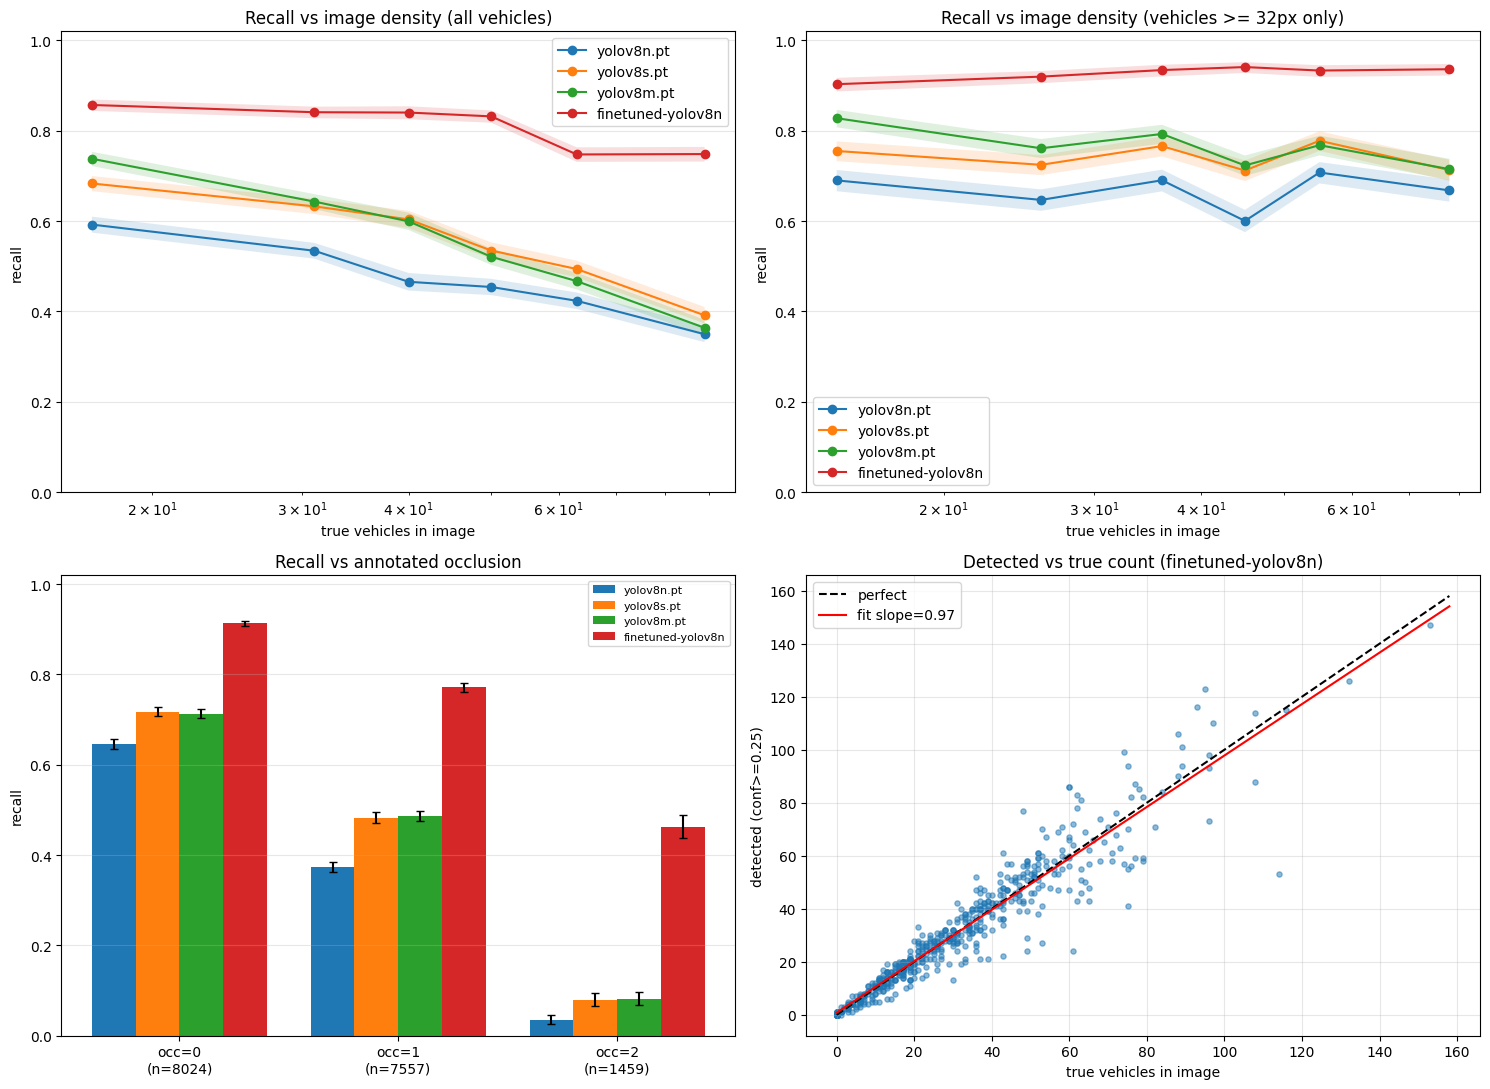

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(15, 11))
for m in MODELS_ALL:
    _, o = TABLES_vd[m]; big = o[o['size'] >= SIZE_MIN]
    curve(ax[0, 0], o.gt_n, o.hit, m); curve(ax[0, 1], big.gt_n, big.hit, m)
ax[0, 0].set_title('Recall vs image density (all vehicles)'); ax[0, 1].set_title(f'Recall vs image density (vehicles >= {SIZE_MIN}px only)')
for a_ in ax[0]: a_.set_xlabel('true vehicles in image'); a_.set_xscale('log'); a_.set_ylabel('recall'); a_.set_ylim(0, 1.02); a_.grid(alpha=.3); a_.legend()
a_ = ax[1, 0]; w_ = 0.8 / len(MODELS_ALL)
for i, m in enumerate(MODELS_ALL):
    _, o = TABLES_vd[m]; g = o.groupby('occ').hit.agg(['sum', 'count']); rec = g['sum'] / g['count']; ci = np.array([wilson(k, n) for k, n in zip(g['sum'], g['count'])])
    a_.bar(np.arange(len(g)) + i * w_, rec, w_, yerr=[rec - ci[:, 0], ci[:, 1] - rec], capsize=3, label=m)
a_.set_xticks(np.arange(len(g)) + 0.4 - w_ / 2); a_.set_xticklabels([f'occ={int(k)}\n(n={n})' for k, n in zip(g.index, g['count'])])
a_.set_title('Recall vs annotated occlusion'); a_.set_ylabel('recall'); a_.set_ylim(0, 1.02); a_.legend(fontsize=8); a_.grid(alpha=.3, axis='y')
mm_ = FTN if FTN in TABLES_vd else MODELS_ALL[-1]; d0, _ = TABLES_vd[mm_]; a_ = ax[1, 1]; a_.scatter(d0.gt_n, d0.pred_n, alpha=.5, s=14); mx = max(d0.gt_n.max(), d0.pred_n.max()) + 5
a_.plot([0, mx], [0, mx], 'k--', label='perfect')
if d0.gt_n.nunique() > 1: s_, b_ = np.polyfit(d0.gt_n, d0.pred_n, 1); a_.plot([0, mx], [b_, s_*mx + b_], 'r-', label=f'fit slope={s_:.2f}')
a_.set_title(f'Detected vs true count ({mm_})'); a_.set_xlabel('true vehicles in image'); a_.set_ylabel(f'detected (conf>={CONF_VD})'); a_.legend(); a_.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'studyC_diagnostics.png'), dpi=150); plt.show()

### 5.7 Study C verdict (pre-registered rule)
Applies the rule stated at the top of Part 5 to the **fine-tuned** detector only. The raw (unadjusted) recall drop is printed next to the standardised drop, so you can see how much of the apparent density effect is explained by size and occlusion.

In [28]:
C_SUPPORTED = None
if FTN in TABLES_vd:
    di, do = TABLES_vd[FTN]; raw = verdict_vd(di, do, size_min=0); big = verdict_vd(di, do, size_min=SIZE_MIN); st = S[S.model == FTN].iloc[0]
    print(f'Fine-tuned detector, sparse (<= {raw["q_lo"]:.0f} vehicles) vs dense (>= {raw["q_hi"]:.0f} vehicles) images:')
    print(f'  raw drop, all vehicles         : {raw["drop"]:+.3f}  CI [{raw["drop_lo"]:+.3f}, {raw["drop_hi"]:+.3f}]')
    print(f'  raw drop, >= {SIZE_MIN}px only         : {big["drop"]:+.3f}  CI [{big["drop_lo"]:+.3f}, {big["drop_hi"]:+.3f}]')
    print(f'  STANDARDISED drop (size x occl.): {st.drop_std:+.3f}  CI [{st.drop_lo:+.3f}, {st.drop_hi:+.3f}]')
    C_SUPPORTED = bool(st.drop_lo > 0)
    print('\nSTUDY C VERDICT (pre-registered):')
    print('SUPPORTED: a density effect remains after holding size and occlusion fixed -> candidate finding, needs replication on a second benchmark.' if C_SUPPORTED
          else 'NOT SUPPORTED: no density effect beyond size and occlusion -> count bias is explained by object size and occlusion.')
else:
    print('Study C was not run (no fine-tuned detector).')

Fine-tuned detector, sparse (<= 19 vehicles) vs dense (>= 39 vehicles) images:
  raw drop, all vehicles         : +0.062  CI [+0.028, +0.096]
  raw drop, >= 32px only         : -0.030  CI [-0.055, -0.007]
  STANDARDISED drop (size x occl.): -0.013  CI [-0.046, +0.019]

STUDY C VERDICT (pre-registered):
NOT SUPPORTED: no density effect beyond size and occlusion -> count bias is explained by object size and occlusion.


# Part 6 | Study E: count metrics and a mechanism test (inference only)

Two additions, both cheap because they only run detectors, never train.

**6.1 Count metrics.** Counting papers report **MAE** (mean absolute count error per image), **RMSE**, **normalised MAE** (MAE divided by the mean true count) and the **net bias** (%). We compute them for every detector across confidence thresholds. This makes the earlier observation quantitative: count bias flips sign with the threshold, and at some thresholds counts look accurate only because false positives cancel misses.

**6.2 Mechanism test (exploratory, designed after seeing Study C).** In Study C the COCO-pretrained detectors kept a density effect after holding size and occlusion fixed, and the fine-tuned detector did not. What could cause a density-dependent recall loss in off-the-shelf detectors? We vary two inference settings and re-run the stratified test for each:
- **NMS IoU threshold (0.5 / 0.7 default / 0.9).** If crowded scenes lose true positives because neighbouring boxes get suppressed, the effect should shrink as the NMS threshold rises.
- **Input size (640 / 1280 / 1600).** If dense scenes hurt because tiny vehicles lose detail, the effect should shrink with larger inputs.
- If neither changes it, the remaining explanation is a **domain gap** (the fine-tuned model sees this kind of scene in training).

We run yolov8s and yolov8m (COCO) and the fine-tuned detector. **Every result here is exploratory**, and the fine-tuned model differs from the COCO models in more than one way, so this can suggest a mechanism but cannot prove one.

### 6.1 MAE / RMSE / normalised MAE / bias across thresholds
`counts_from` takes the number of detections above each confidence threshold and compares it with the true count per image (no box matching is needed for count metrics, so this is fast). The table below shows thresholds 0.25, 0.4 and 0.5 for VisDrone (all four detectors) and the highway set. The full sweep (0.1 to 0.7) is saved to CSV and drawn in the paper figure.

In [29]:
SWEEP = [0.1, 0.25, 0.4, 0.5, 0.6, 0.7]
def counts_from(det, conf, gt_list_):
    pred = np.array([(pc >= conf).sum() for pb, pc in det]); gt = np.array([len(g) for g in gt_list_]); return gt, pred
def cm_row(gt, pred):
    e = pred - gt; return dict(MAE=np.abs(e).mean(), RMSE=np.sqrt((e ** 2).mean()), nMAE=np.abs(e).mean() / gt.mean(), bias_pct=100 * e.sum() / gt.sum())
CM_ROWS = []
for m in MODELS_ALL:
    for c in SWEEP:
        gt_, pr_ = counts_from(DET_vd[m], c, gt_vd); CM_ROWS.append(dict(dataset='VisDrone', model=m, conf=c, **cm_row(gt_, pr_)))
for c in SWEEP:
    gt_, pr_ = counts_from(val_det, c, gts); CM_ROWS.append(dict(dataset='Highway', model='finetuned-yolov8n', conf=c, **cm_row(gt_, pr_)))
CM = pd.DataFrame(CM_ROWS); CM.to_csv('studyE_count_metrics.csv', index=False)
print(CM[CM.conf.isin([0.25, 0.4, 0.5])].round(3).to_string(index=False))
print('\nMAE/RMSE are in vehicles per image; nMAE = MAE / mean true count; bias_pct = 100*(sum predicted - sum true)/sum true.')
best = CM[CM.dataset == 'VisDrone'].loc[lambda d: d.groupby('model').MAE.idxmin()][['model', 'conf', 'MAE', 'RMSE', 'nMAE', 'bias_pct']]
print('\nMAE-minimising threshold per VisDrone detector (chosen AFTER seeing the ground truth, so an oracle, not achievable in practice):'); print(best.round(3).to_string(index=False))

 dataset             model  conf    MAE   RMSE  nMAE  bias_pct
VisDrone        yolov8n.pt  0.25 13.378 20.925 0.430   -40.499
VisDrone        yolov8n.pt  0.40 18.471 26.042 0.594   -59.190
VisDrone        yolov8n.pt  0.50 21.303 28.907 0.685   -68.451
VisDrone        yolov8s.pt  0.25 11.214 18.674 0.361   -31.884
VisDrone        yolov8s.pt  0.40 14.914 22.746 0.480   -47.494
VisDrone        yolov8s.pt  0.50 17.405 25.280 0.560   -55.880
VisDrone        yolov8m.pt  0.25 11.755 19.675 0.378   -33.850
VisDrone        yolov8m.pt  0.40 14.797 23.103 0.476   -46.567
VisDrone        yolov8m.pt  0.50 16.849 25.263 0.542   -53.844
VisDrone finetuned-yolov8n  0.25  4.491  7.526 0.144    -0.393
VisDrone finetuned-yolov8n  0.40  6.982 11.876 0.225   -20.153
VisDrone finetuned-yolov8n  0.50  9.186 15.023 0.295   -28.685
 Highway finetuned-yolov8n  0.25  2.067  2.951 0.199    18.356
 Highway finetuned-yolov8n  0.40  1.544  2.219 0.148    10.779
 Highway finetuned-yolov8n  0.50  1.311  1.801 0.126   

### 6.2 Mechanism grid: NMS IoU x input size
For each setting the detector is run on the 548 VisDrone validation images (detections in ignored regions dropped, confidence threshold 0.25), and we record the overall recall, the raw sparse-vs-dense recall drop, and the **standardised drop** (same size x occlusion mix in both groups) with a 95% bootstrap CI (500 resamples to save time). The baseline for the COCO models is input 1280 with NMS IoU 0.7 (as in Study B); for the fine-tuned detector it is 960 with NMS 0.7. Progress is printed run by run, so you can see the time each takes.

In [30]:
import time
MECH_MODELS = ['yolov8s.pt', 'yolov8m.pt']; MECH_NMS = [0.5, 0.7, 0.9]; MECH_IMGSZ = [640, 1280, 1600]; MECH_FT_IMGSZ = [960, 1280]

def build_tables_det(det, conf):
    rows_img, rows_obj = [], []
    for name, gt, occ, (pb, pc) in zip(names_vd, gt_vd, occ_vd, det):
        keep = pc >= conf; hit = match_greedy(gt, pb[keep], pc[keep]); tp = int(hit.sum()); pred_n = int(keep.sum()); gt_n = len(gt)
        rows_img.append(dict(image=name, gt_n=gt_n, pred_n=pred_n, tp=tp, fp=pred_n - tp, fn=gt_n - tp))
        if gt_n:
            f = gt_features(gt); f['occ'] = occ.ravel(); f['hit'] = hit.astype(int); f['image'] = name; f['gt_n'] = gt_n; rows_obj.append(f)
    return pd.DataFrame(rows_img), pd.concat(rows_obj, ignore_index=True)

def run_det(mdl, imgsz, nms, coco_only):
    out = []; bs = 4 if imgsz > 1280 else 8
    for i in range(0, len(img_paths_vd), bs):
        kw = dict(source=img_paths_vd[i:i + bs], imgsz=imgsz, conf=0.05, iou=nms, max_det=1000, verbose=False, device=DEV)
        if coco_only: kw['classes'] = COCO_VEH
        for k, r in enumerate(mdl.predict(**kw)):
            pb = r.boxes.xyxy.cpu().numpy(); pc = r.boxes.conf.cpu().numpy(); drop = in_ignore(pb, ign_vd[i + k]); out.append((pb[~drop], pc[~drop]))
    return out

def mech_row(name, det, imgsz, nms, secs):
    di, do = build_tables_det(det, CONF_VD); st = stratified_drop(di, do, n_boot=500); rw = verdict_vd(di, do, 0, n_boot=500)
    return dict(model=name, imgsz=imgsz, nms=nms, recall=di.tp.sum() / di.gt_n.sum(), raw_drop=rw['drop'], raw_lo=rw['drop_lo'], raw_hi=rw['drop_hi'],
                std_drop=st['drop_std'], std_lo=st['drop_lo'], std_hi=st['drop_hi'], seconds=round(secs))

MECH = []
for mn in MECH_MODELS:
    mdl = YOLO(mn)
    for sz in MECH_IMGSZ:
        for nms in MECH_NMS:
            t0 = time.time(); det = run_det(mdl, sz, nms, True); MECH.append(mech_row(mn, det, sz, nms, time.time() - t0))
            r_ = MECH[-1]; print(f"{mn} imgsz={sz} nms={nms}: recall {r_['recall']:.3f} | standardised drop {r_['std_drop']:+.3f} [{r_['std_lo']:+.3f}, {r_['std_hi']:+.3f}] ({r_['seconds']} s)")
if FT_BEST:
    mdl = YOLO(FT_BEST)
    for sz in MECH_FT_IMGSZ:
        for nms in MECH_NMS:
            t0 = time.time(); det = run_det(mdl, sz, nms, False); MECH.append(mech_row(FTN, det, sz, nms, time.time() - t0))
            r_ = MECH[-1]; print(f"{FTN} imgsz={sz} nms={nms}: recall {r_['recall']:.3f} | standardised drop {r_['std_drop']:+.3f} [{r_['std_lo']:+.3f}, {r_['std_hi']:+.3f}] ({r_['seconds']} s)")
MECH_DF = pd.DataFrame(MECH); MECH_DF.to_csv('studyE_mechanism.csv', index=False)

yolov8s.pt imgsz=640 nms=0.5: recall 0.386 | standardised drop +0.115 [+0.073, +0.154] (9 s)
yolov8s.pt imgsz=640 nms=0.7: recall 0.387 | standardised drop +0.114 [+0.072, +0.152] (9 s)
yolov8s.pt imgsz=640 nms=0.9: recall 0.389 | standardised drop +0.114 [+0.071, +0.153] (10 s)
yolov8s.pt imgsz=1280 nms=0.5: recall 0.557 | standardised drop +0.094 [+0.051, +0.138] (23 s)
yolov8s.pt imgsz=1280 nms=0.7: recall 0.559 | standardised drop +0.093 [+0.049, +0.136] (23 s)
yolov8s.pt imgsz=1280 nms=0.9: recall 0.561 | standardised drop +0.093 [+0.050, +0.136] (23 s)
yolov8s.pt imgsz=1600 nms=0.5: recall 0.599 | standardised drop +0.075 [+0.028, +0.118] (33 s)
yolov8s.pt imgsz=1600 nms=0.7: recall 0.601 | standardised drop +0.074 [+0.027, +0.117] (33 s)
yolov8s.pt imgsz=1600 nms=0.9: recall 0.604 | standardised drop +0.075 [+0.029, +0.119] (33 s)
yolov8m.pt imgsz=640 nms=0.5: recall 0.430 | standardised drop +0.148 [+0.106, +0.186] (16 s)
yolov8m.pt imgsz=640 nms=0.7: recall 0.431 | standardise

### 6.3 Reading the mechanism grid
For each detector we compare the standardised drop at the baseline setting with the drop when only the NMS IoU changes (input size fixed) and when only the input size changes (NMS 0.7 fixed). A ratio near 1 means the setting does not matter; a ratio well below 1 (or a CI that now includes zero) means the setting explains part of the effect. The printed guide states which mechanism, if any, the numbers point to. Treat this as **exploratory evidence** that generates a hypothesis for future work.

In [31]:
def _get(m, sz, nms):
    r = MECH_DF[(MECH_DF.model == m) & (MECH_DF.imgsz == sz) & (MECH_DF.nms == nms)]; return r.iloc[0] if len(r) else None
def _ratio(r, base):
    return f'{r.std_drop / base.std_drop:.2f}' if base.std_lo > 0 else 'n/a (baseline effect not significant)'
MECH_SUMMARY = []
for m in list(MECH_MODELS) + ([FTN] if FTN in set(MECH_DF.model) else []):
    bsz = 960 if m == FTN else 1280; base = _get(m, bsz, 0.7)
    if base is None: continue
    print(f'--- {m}: baseline (imgsz {bsz}, NMS 0.7) standardised drop = {base.std_drop:+.3f} [{base.std_lo:+.3f}, {base.std_hi:+.3f}]')
    for nms in (0.5, 0.9):
        r = _get(m, bsz, nms); print(f'    NMS IoU {nms}: {r.std_drop:+.3f} [{r.std_lo:+.3f}, {r.std_hi:+.3f}]  ratio to baseline {_ratio(r, base)}')
    for sz in sorted(set(MECH_DF[MECH_DF.model == m].imgsz) - {bsz}):
        r = _get(m, sz, 0.7)
        if r is not None: print(f'    imgsz {sz}: {r.std_drop:+.3f} [{r.std_lo:+.3f}, {r.std_hi:+.3f}]  ratio to baseline {_ratio(r, base)}')
    MECH_SUMMARY.append((m, base))
print('''\nGUIDE: NMS row ratios well below 1 -> crowded-scene box suppression explains part of the density effect.
       imgsz ratios well below 1 -> lost detail on tiny vehicles in dense scenes explains part of it.
       Ratios near 1 for both -> neither setting matters; the residual is consistent with a domain gap (the fine-tuned model sees this domain in training).
       A CI including 0 means the effect is no longer distinguishable from none. Ratios are only meaningful when the baseline effect is significant.
       All of this is exploratory.''')

--- yolov8s.pt: baseline (imgsz 1280, NMS 0.7) standardised drop = +0.093 [+0.049, +0.136]
    NMS IoU 0.5: +0.094 [+0.051, +0.138]  ratio to baseline 1.01
    NMS IoU 0.9: +0.093 [+0.050, +0.136]  ratio to baseline 1.01
    imgsz 640: +0.114 [+0.072, +0.152]  ratio to baseline 1.23
    imgsz 1600: +0.074 [+0.027, +0.117]  ratio to baseline 0.80
--- yolov8m.pt: baseline (imgsz 1280, NMS 0.7) standardised drop = +0.159 [+0.115, +0.200]
    NMS IoU 0.5: +0.158 [+0.114, +0.199]  ratio to baseline 0.99
    NMS IoU 0.9: +0.157 [+0.114, +0.199]  ratio to baseline 0.99
    imgsz 640: +0.148 [+0.106, +0.185]  ratio to baseline 0.93
    imgsz 1600: +0.138 [+0.094, +0.181]  ratio to baseline 0.87
--- finetuned-yolov8n: baseline (imgsz 960, NMS 0.7) standardised drop = -0.013 [-0.047, +0.018]
    NMS IoU 0.5: -0.007 [-0.041, +0.024]  ratio to baseline n/a (baseline effect not significant)
    NMS IoU 0.9: -0.018 [-0.051, +0.014]  ratio to baseline n/a (baseline effect not significant)
    imgsz 1

# Part 7 | Study F: camera-based non-invasive traffic "vital signs" and their sensitivity to detector settings

**Idea.** A detector + tracker turns a roadside video into the basic measurements a traffic engineer would otherwise get from in-road loop detectors:
- **Density**: vehicles visible per frame.
- **Flow**: vehicles per minute crossing a **virtual loop** (a counting line placed across the road).
- **Speed**: how fast tracked vehicles move. The video has no camera calibration, so speed is reported in **vehicle lengths per second** (unit-free, comparable across settings) and in pixels per second. A typical car is about 4-5 m long, so 1 vehicle length per second is roughly 16-18 km/h, but that conversion is only an assumption, not a measurement.

**Question.** Each vital sign depends on the detector's operating point. **How much do density, flow and speed change when only the confidence threshold and the input size change?** This connects to the earlier finding that raw counts are threshold-dependent and can be right for the wrong reasons.

**Design.** We track the sample video with the highway detector for a grid of confidence thresholds (0.25, 0.4, 0.55, 0.7) and input sizes (480, 640, 960). The reference setting is confidence 0.4 at 640 px (the setting used for the figures). The counting line's position and orientation are chosen once, automatically, from the reference run (perpendicular to the dominant motion direction, at the middle of the frame) and then **kept fixed** so all settings are comparable. A vehicle is counted once per direction when its track crosses the line.

**Honest limits.** One video and **no ground truth**: this measures the *sensitivity* of the vital signs to detector settings, not their *accuracy*. An accuracy claim would need labelled video or a manual count. If you can watch the video and count the vehicles that cross the drawn line, enter the number in `MANUAL_CROSSINGS` below and the notebook will also report the count error for every setting. Track-ID switches (one vehicle getting two IDs) inflate flow and vehicle misses deflate it, which is exactly the sensitivity we want to expose.

### 7.1 Track the video over the grid and compute the vital signs
`track_stream_cfg` runs YOLOv8 + ByteTrack with a given threshold and input size (with a simple centroid-tracker fallback). A **fresh model is loaded for every run** so tracker state never leaks from one run into the next. `vitals` computes density (mean and max vehicles per frame), flow (line crossings per minute, split by direction), and speed (median over tracks of at least 15 frames, along the motion axis).

In [32]:
import time
F_CONFS = [0.25, 0.4, 0.55, 0.7]; F_IMGSZ = [480, 640, 960]; F_REF = (0.4, 640)
MANUAL_CROSSINGS = None   # optional: how many vehicles YOU count crossing the drawn line in the whole video (leave None to skip)
MIN_TRACK = 15            # minimum track length (frames) for speed

def track_stream_cfg(mdl, video, conf, imgsz):
    started = False
    try:
        for r in mdl.track(source=video, stream=True, persist=True, tracker='bytetrack.yaml', conf=conf, imgsz=imgsz, verbose=False, device=DEV):
            b = r.boxes; xyxy = b.xyxy.cpu().numpy(); ids = b.id.int().cpu().numpy() if b.id is not None else np.full(len(xyxy), -1)
            started = True; yield r.orig_shape, xyxy, ids
        return
    except Exception as e:
        if started: raise
        print('Built-in tracker unavailable (', type(e).__name__, ') -> using simple centroid tracker')
    nxt, prev = 0, {}
    for r in mdl.predict(source=video, stream=True, conf=conf, imgsz=imgsz, verbose=False, device=DEV):
        xyxy = r.boxes.xyxy.cpu().numpy(); cur = {}; ids = np.full(len(xyxy), -1); used = set()
        for j, b in enumerate(xyxy):
            c = np.array([(b[0] + b[2]) / 2, (b[1] + b[3]) / 2]); best, bd = None, 60.0
            for i, pc in prev.items():
                d = np.hypot(*(c - pc))
                if i not in used and d < bd: best, bd = i, d
            if best is None: best = nxt; nxt += 1
            used.add(best); ids[j] = best; cur[best] = c
        prev = cur; yield r.orig_shape, xyxy, ids

def track_run(conf, imgsz):
    mdl = YOLO(BEST); hist, counts, shape = {}, [], None      # fresh model = fresh tracker state
    for f, (shp, xyxy, ids) in enumerate(track_stream_cfg(mdl, SAMPLE_VID, conf, imgsz)):
        shape = shp; counts.append(len(xyxy))
        for b, i in zip(xyxy, ids):
            if i >= 0: hist.setdefault(int(i), []).append((f, (b[0] + b[2]) / 2, (b[1] + b[3]) / 2, b[2] - b[0], b[3] - b[1]))
    return hist, np.array(counts), shape

def motion_axis(hist):
    dx = [abs(p[-1][1] - p[0][1]) for p in hist.values() if len(p) >= MIN_TRACK]; dy = [abs(p[-1][2] - p[0][2]) for p in hist.values() if len(p) >= MIN_TRACK]
    return 0 if np.mean(dx) >= np.mean(dy) else 1      # 0: vehicles move along x (vertical counting line), 1: along y (horizontal line)

def vitals(hist, counts, fps, axis, line):
    dur = len(counts) / fps; cross = {1: 0, -1: 0}; speeds, rel = [], []
    for pts in hist.values():
        p = np.array([q[1 + axis] for q in pts]); fr = np.array([q[0] for q in pts]); s = np.sign(p - line); nz = np.where(s[:-1] * s[1:] < 0)[0]
        if len(nz): cross[int(np.sign(p[nz[0] + 1] - p[nz[0]]))] += 1
        if len(pts) >= MIN_TRACK and fr[-1] > fr[0]:
            v = abs(p[-1] - p[0]) / ((fr[-1] - fr[0]) / fps); Lv = np.median([q[3 + axis] for q in pts]); speeds.append(v); rel.append(v / max(Lv, 1.0))
    tot = cross[1] + cross[-1]
    return dict(density_mean=float(np.mean(counts)), density_max=int(np.max(counts)), crossings=tot, cross_pos=cross[1], cross_neg=cross[-1], flow_per_min=tot / dur * 60,
                speed_px_s=float(np.median(speeds)) if speeds else np.nan, speed_len_s=float(np.median(rel)) if rel else np.nan, n_tracks=len(hist), n_frames=len(counts), duration_s=dur)

VF_DF = None; VF_SUMMARY = None
if SAMPLE_VID:
    cap = cv2.VideoCapture(SAMPLE_VID); F_FPS = cap.get(cv2.CAP_PROP_FPS) or 25.0; cap.release()
    RUNS = {}
    for c in [F_REF[0]] + [x for x in F_CONFS if x != F_REF[0]]:
        for sz in ([F_REF[1]] + [x for x in F_IMGSZ if x != F_REF[1]] if c == F_REF[0] else F_IMGSZ):
            t0 = time.time(); RUNS[(c, sz)] = track_run(c, sz); print(f'tracked conf={c} imgsz={sz}: {len(RUNS[(c, sz)][1])} frames, {len(RUNS[(c, sz)][0])} tracks ({time.time() - t0:.0f} s)')
    ref_hist, ref_counts, F_SHAPE = RUNS[F_REF]; F_AXIS = motion_axis(ref_hist); F_LINE = (F_SHAPE[1] if F_AXIS == 0 else F_SHAPE[0]) / 2
    print(f"Motion is mainly along the {'x (horizontal)' if F_AXIS == 0 else 'y (vertical)'} axis -> counting line at {'x' if F_AXIS == 0 else 'y'} = {F_LINE:.0f} px (fixed for all settings)")
    rows = []
    for (c, sz), (h, cn, _) in RUNS.items():
        v = vitals(h, cn, F_FPS, F_AXIS, F_LINE); v.update(conf=c, imgsz=sz); rows.append(v)
    VF_DF = pd.DataFrame(rows).sort_values(['imgsz', 'conf']).reset_index(drop=True)
    if MANUAL_CROSSINGS is not None: VF_DF['crossing_error'] = VF_DF.crossings - MANUAL_CROSSINGS; VF_DF['crossing_error_pct'] = 100 * VF_DF.crossing_error / MANUAL_CROSSINGS
    print(VF_DF[['conf', 'imgsz', 'density_mean', 'flow_per_min', 'crossings', 'cross_pos', 'cross_neg', 'speed_len_s', 'speed_px_s', 'n_tracks'] + (['crossing_error_pct'] if MANUAL_CROSSINGS is not None else [])].round(2).to_string(index=False))
    VF_DF.to_csv('studyF_vital_signs.csv', index=False)
else:
    print('sample_video.mp4 not found; Study F skipped.')

tracked conf=0.4 imgsz=640: 601 frames, 45 tracks (9 s)
tracked conf=0.4 imgsz=480: 601 frames, 46 tracks (9 s)
tracked conf=0.4 imgsz=960: 601 frames, 43 tracks (11 s)
tracked conf=0.25 imgsz=480: 601 frames, 53 tracks (10 s)
tracked conf=0.25 imgsz=640: 601 frames, 48 tracks (9 s)
tracked conf=0.25 imgsz=960: 601 frames, 48 tracks (11 s)
tracked conf=0.55 imgsz=480: 601 frames, 36 tracks (9 s)
tracked conf=0.55 imgsz=640: 601 frames, 38 tracks (9 s)
tracked conf=0.55 imgsz=960: 601 frames, 40 tracks (10 s)
tracked conf=0.7 imgsz=480: 601 frames, 31 tracks (9 s)
tracked conf=0.7 imgsz=640: 601 frames, 34 tracks (10 s)
tracked conf=0.7 imgsz=960: 601 frames, 35 tracks (11 s)
Motion is mainly along the y (vertical) axis -> counting line at y = 360 px (fixed for all settings)
 conf  imgsz  density_mean  flow_per_min  crossings  cross_pos  cross_neg  speed_len_s  speed_px_s  n_tracks
 0.25    480          5.28         92.85         31         18         13         2.10      101.54        

### 7.2 How sensitive is each vital sign? (summary table)
For each vital sign we report the value at the **reference setting** (confidence 0.4, 640 px), the minimum and maximum over the whole grid, and the **range as a percentage of the reference** ((max - min) / reference). We also split the sensitivity into a **threshold effect** (range over the four confidence thresholds at 640 px) and an **input-size effect** (range over the three input sizes at confidence 0.4). A large range means that vital sign is not trustworthy unless the detector's operating point is calibrated against ground truth; a small range means it is robust to those settings. Note that robust does not mean accurate: without ground truth we cannot say the value is correct.

In [33]:
if VF_DF is not None:
    ref = VF_DF[(VF_DF.conf == F_REF[0]) & (VF_DF.imgsz == F_REF[1])].iloc[0]; out = []
    for key, name in [('density_mean', 'density (vehicles/frame)'), ('flow_per_min', 'flow (vehicles/min)'), ('speed_len_s', 'speed (vehicle lengths/s)')]:
        thr = VF_DF[VF_DF.imgsz == F_REF[1]][key]; siz = VF_DF[VF_DF.conf == F_REF[0]][key]; r0 = ref[key]
        out.append(dict(vital_sign=name, reference=r0, grid_min=VF_DF[key].min(), grid_max=VF_DF[key].max(), grid_range_pct=100 * (VF_DF[key].max() - VF_DF[key].min()) / r0,
                        threshold_range_pct=100 * (thr.max() - thr.min()) / r0, size_range_pct=100 * (siz.max() - siz.min()) / r0))
    VF_SUMMARY = pd.DataFrame(out); print(VF_SUMMARY.round(2).to_string(index=False)); VF_SUMMARY.to_csv('studyF_sensitivity_summary.csv', index=False)
    print('\nGUIDE: a range of 10% or less means the vital sign is fairly stable across detector settings; 30% or more means it depends strongly on the operating point.')
    print('Density and flow are counts, so they fall as the threshold rises (missed vehicles); flow can also be inflated at LOW thresholds by track-ID switches. Speed is a per-track median, so it is usually the most stable.')
    if MANUAL_CROSSINGS is not None:
        best_row = VF_DF.loc[VF_DF.crossing_error.abs().idxmin()]; print(f"Manual check: closest setting to your count ({MANUAL_CROSSINGS}) is conf={best_row.conf}, imgsz={int(best_row.imgsz)} with error {best_row.crossing_error:+.0f} ({best_row.crossing_error_pct:+.1f}%).")
else:
    print('Study F was not run.')

               vital_sign  reference  grid_min  grid_max  grid_range_pct  threshold_range_pct  size_range_pct
 density (vehicles/frame)       6.18      3.15      6.70           57.47                47.05           27.68
      flow (vehicles/min)      89.85     83.86     92.85           10.00                 3.33            0.00
speed (vehicle lengths/s)       2.18      2.03      2.41           17.10                11.37           10.46

GUIDE: a range of 10% or less means the vital sign is fairly stable across detector settings; 30% or more means it depends strongly on the operating point.
Density and flow are counts, so they fall as the threshold rises (missed vehicles); flow can also be inflated at LOW thresholds by track-ID switches. Speed is a per-track median, so it is usually the most stable.


### 7.3 Paper-ready Figure 3: traffic vital signs and their sensitivity
One compact full-width figure (6.9 in) with four panels: **(a)** a video frame showing the virtual loop (counting line) and the flow directions, and **(b)-(d)** density, flow and speed against the confidence threshold, one line per input size, with the reference setting circled. If you entered `MANUAL_CROSSINGS`, a dotted line in (c) shows your manual flow. Saved as vector PDF and 300-dpi PNG in `paper_assets/`, plus a ready-to-paste LaTeX table of the sensitivity summary (`table_vitals.tex`).

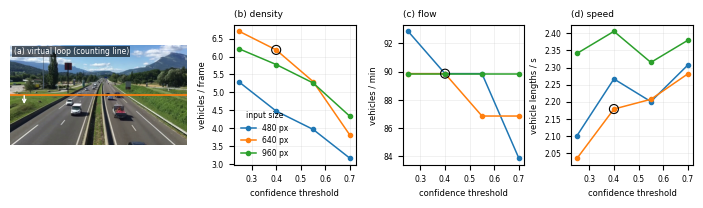

Saved paper_assets/fig3_vital_signs.pdf and .png
\begin{table}[t]
\centering
\small
\begin{tabular}{lcccccc}
\hline
Vital sign & Ref. & Min & Max & Range (\%) & Thr. (\%) & Size (\%) \\
\hline
density (vehicles/frame) & 6.18 & 3.15 & 6.70 & 57 & 47 & 28 \\
flow (vehicles/min) & 89.85 & 83.86 & 92.85 & 10 & 3 & 0 \\
speed (vehicle lengths/s) & 2.18 & 2.03 & 2.41 & 17 & 11 & 10 \\
\hline
\end{tabular}
\caption{Sensitivity of camera-derived traffic vital signs to detector settings (confidence 0.25-0.7, input 480-960 px). Reference: confidence 0.4, 640 px. Range is (max - min) as a percentage of the reference; Thr. and Size vary one setting at a time.}
\label{tab:vitals}
\end{table}


In [34]:
def tex_table(header, rows, colfmt, caption, label):
    L = ['\\begin{table}[t]', '\\centering', '\\small', '\\begin{tabular}{' + colfmt + '}', '\\hline', ' & '.join(header) + ' \\\\', '\\hline']
    L += [' & '.join(str(x) for x in r) + ' \\\\' for r in rows]
    L += ['\\hline', '\\end{tabular}', '\\caption{' + caption + '}', '\\label{' + label + '}', '\\end{table}']; return '\n'.join(L)

def paper_fig3(base, W=6.9):
    cap = cv2.VideoCapture(SAMPLE_VID); n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); cap.set(cv2.CAP_PROP_POS_FRAMES, max(n // 2, 0)); ok, fr = cap.read(); cap.release()
    fr = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB) if ok else np.full((F_SHAPE[0], F_SHAPE[1], 3), 128, np.uint8); Hh, Wd = fr.shape[:2]
    with plt.rc_context({'font.size': 6, 'axes.titlesize': 6.5, 'axes.labelsize': 6, 'xtick.labelsize': 5.5, 'ytick.labelsize': 5.5, 'legend.fontsize': 5.5, 'lines.linewidth': 1.1, 'lines.markersize': 3}):
        fig, ax = plt.subplots(1, 4, figsize=(W, 1.95), gridspec_kw=dict(width_ratios=[1.45, 1, 1, 1]))
        a = ax[0]; a.imshow(fr); a.axis('off')
        if F_AXIS == 0: a.axvline(F_LINE, color='#ff7f0e', lw=1.2); a.annotate('', xy=(F_LINE + 0.12 * Wd, 0.08 * Hh), xytext=(F_LINE - 0.02 * Wd, 0.08 * Hh), arrowprops=dict(arrowstyle='->', color='white', lw=1))
        else: a.axhline(F_LINE, color='#ff7f0e', lw=1.2); a.annotate('', xy=(0.08 * Wd, F_LINE + 0.12 * Hh), xytext=(0.08 * Wd, F_LINE - 0.02 * Hh), arrowprops=dict(arrowstyle='->', color='white', lw=1))
        a.text(0.02, 0.98, '(a) virtual loop (counting line)', transform=a.transAxes, fontsize=5.5, color='white', va='top', ha='left', bbox=dict(boxstyle='square,pad=0.15', fc='black', ec='none', alpha=.6))
        for k, (key, ttl, yl) in enumerate([('density_mean', '(b) density', 'vehicles / frame'), ('flow_per_min', '(c) flow', 'vehicles / min'), ('speed_len_s', '(d) speed', 'vehicle lengths / s')]):
            b_ = ax[k + 1]
            for j, sz in enumerate(F_IMGSZ):
                d_ = VF_DF[VF_DF.imgsz == sz].sort_values('conf'); b_.plot(d_.conf, d_[key], 'o-', color=f'C{j}', label=f'{sz} px')
            r_ = VF_DF[(VF_DF.conf == F_REF[0]) & (VF_DF.imgsz == F_REF[1])].iloc[0]; b_.scatter([F_REF[0]], [r_[key]], s=42, facecolors='none', edgecolors='k', lw=.8, zorder=5)
            if key == 'flow_per_min' and MANUAL_CROSSINGS is not None: b_.axhline(MANUAL_CROSSINGS / r_['duration_s'] * 60, color='k', ls=':', lw=.8, label='manual')
            b_.set_title(ttl, loc='left'); b_.set_xlabel('confidence threshold'); b_.set_ylabel(yl); b_.grid(alpha=.3, lw=.4)
            if k == 0: b_.legend(frameon=False, title='input size', title_fontsize=5.5)
        plt.tight_layout(pad=0.4, w_pad=0.7); fig.savefig(base + '.pdf', dpi=300, bbox_inches='tight'); fig.savefig(base + '.png', dpi=300, bbox_inches='tight'); plt.show()

if VF_DF is not None:
    paper_fig3(os.path.join(PAPER_DIR, 'fig3_vital_signs')); print('Saved paper_assets/fig3_vital_signs.pdf and .png')
    rowsF = [[r.vital_sign, f'{r.reference:.2f}', f'{r.grid_min:.2f}', f'{r.grid_max:.2f}', f'{r.grid_range_pct:.0f}', f'{r.threshold_range_pct:.0f}', f'{r.size_range_pct:.0f}'] for r in VF_SUMMARY.itertuples()]
    TF = tex_table(['Vital sign', 'Ref.', 'Min', 'Max', 'Range (\\%)', 'Thr. (\\%)', 'Size (\\%)'], rowsF, 'lcccccc', 'Sensitivity of camera-derived traffic vital signs to detector settings (confidence 0.25-0.7, input 480-960 px). Reference: confidence 0.4, 640 px. Range is (max - min) as a percentage of the reference; Thr. and Size vary one setting at a time.', 'tab:vitals')
    open(os.path.join(PAPER_DIR, 'table_vitals.tex'), 'w').write(TF); print(TF)

# Part 8 | Paper assets: merged Figure 2 and LaTeX tables

**Figure 2** merges the quantitative results into one full-width figure (6.9 in): **(a)** recall vs image density for all four detectors, **(b)** the same for vehicles >= 32 px only (the density effect largely disappears), **(c)** recall by annotated occlusion, **(d)** net count bias vs confidence threshold (it flips sign), **(e)** normalised MAE vs threshold, and **(f)** the mechanism test (standardised density effect vs input size for three NMS settings; dashed = fine-tuned detector). Saved as vector PDF and 300-dpi PNG.

**Figure 3** (traffic vital signs) was written in Part 7. **Tables** are written as ready-to-paste LaTeX (`\hline` rules, no extra packages): Table 1 count metrics, Table 2 the density test (raw and standardised), Table 3 the mechanism grid. Copy them from `paper_assets/`.

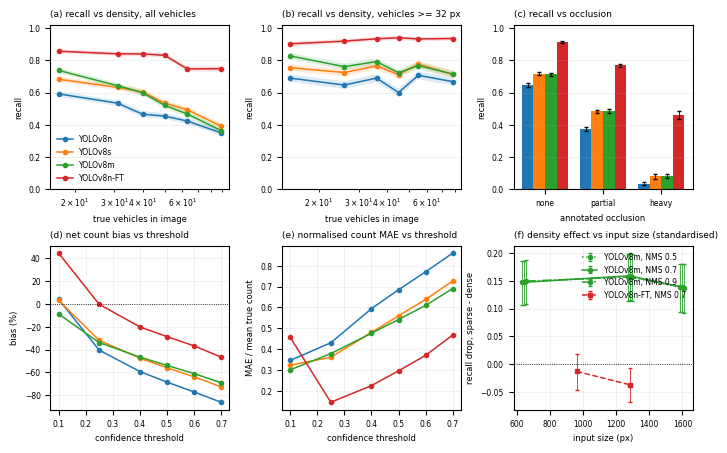

Saved paper_assets/fig2_results.pdf and .png
\begin{table}[t]
\centering
\small
\begin{tabular}{lccc}
\hline
Detector & Raw drop, all & Raw drop, $\geq$32 px & Standardised drop \\
\hline
YOLOv8n & +0.175 [+0.131, +0.221] & +0.037 [-0.018, +0.094] & +0.047 [+0.006, +0.089] \\
YOLOv8s & +0.190 [+0.144, +0.234] & +0.031 [-0.027, +0.093] & +0.093 [+0.048, +0.136] \\
YOLOv8m & +0.270 [+0.226, +0.312] & +0.100 [+0.044, +0.159] & +0.159 [+0.115, +0.201] \\
YOLOv8n-FT & +0.062 [+0.026, +0.096] & -0.030 [-0.056, -0.006] & -0.013 [-0.047, +0.019] \\
\hline
\end{tabular}
\caption{Recall in the sparsest minus the densest third of VisDrone val images, with 95\% bootstrap CIs over images. The standardised drop holds the size-by-occlusion mix fixed.}
\label{tab:density}
\end{table}

Also saved: table_counts.tex, table_density.tex, table_mechanism.tex in paper_assets/


In [35]:
def pretty(m): return {'finetuned-yolov8n': 'YOLOv8n-FT'}.get(m, m.replace('.pt', '').replace('yolov8', 'YOLOv8'))

def paper_fig2(base, W=6.9):
    with plt.rc_context({'font.size': 6, 'axes.titlesize': 6.5, 'axes.labelsize': 6, 'xtick.labelsize': 5.5, 'ytick.labelsize': 5.5, 'legend.fontsize': 5.5, 'lines.linewidth': 1.1, 'lines.markersize': 3}):
        fig, ax = plt.subplots(2, 3, figsize=(W, 4.4)); cols = {m: f'C{i}' for i, m in enumerate(MODELS_ALL)}
        for m in MODELS_ALL:
            _, o = TABLES_vd[m]; big = o[o['size'] >= SIZE_MIN]
            curve(ax[0, 0], o.gt_n, o.hit, pretty(m)); curve(ax[0, 1], big.gt_n, big.hit, pretty(m))
        ax[0, 0].set_title('(a) recall vs density, all vehicles', loc='left'); ax[0, 1].set_title(f'(b) recall vs density, vehicles >= {SIZE_MIN} px', loc='left')
        for a_ in ax[0, :2]: a_.set_xscale('log'); a_.set_xlabel('true vehicles in image'); a_.set_ylabel('recall'); a_.set_ylim(0, 1.02); a_.grid(alpha=.3, lw=.4)
        ax[0, 0].legend(loc='lower left', frameon=False)
        a_ = ax[0, 2]; w_ = 0.8 / len(MODELS_ALL)
        for i, m in enumerate(MODELS_ALL):
            _, o = TABLES_vd[m]; g = o.groupby('occ').hit.agg(['sum', 'count']); rec = g['sum'] / g['count']; ci = np.array([wilson(k, n) for k, n in zip(g['sum'], g['count'])])
            a_.bar(np.arange(len(g)) + i * w_, rec, w_, yerr=[rec - ci[:, 0], ci[:, 1] - rec], capsize=1.5, color=cols[m], error_kw=dict(lw=.6))
        a_.set_xticks(np.arange(len(g)) + 0.4 - w_ / 2); a_.set_xticklabels(['none', 'partial', 'heavy']); a_.set_xlabel('annotated occlusion'); a_.set_ylabel('recall'); a_.set_ylim(0, 1.02)
        a_.set_title('(c) recall vs occlusion', loc='left'); a_.grid(alpha=.3, lw=.4, axis='y')
        V = CM[CM.dataset == 'VisDrone']
        for m in MODELS_ALL:
            d_ = V[V.model == m]; ax[1, 0].plot(d_.conf, d_.bias_pct, 'o-', color=cols[m]); ax[1, 1].plot(d_.conf, d_.nMAE, 'o-', color=cols[m])
        ax[1, 0].axhline(0, color='k', lw=.6, ls=':'); ax[1, 0].set_title('(d) net count bias vs threshold', loc='left'); ax[1, 0].set_ylabel('bias (%)')
        ax[1, 1].set_title('(e) normalised count MAE vs threshold', loc='left'); ax[1, 1].set_ylabel('MAE / mean true count')
        for a_ in ax[1, :2]: a_.set_xlabel('confidence threshold'); a_.grid(alpha=.3, lw=.4)
        a_ = ax[1, 2]
        if 'MECH_DF' in globals() and len(MECH_DF):
            sty = {0.5: 'o:', 0.7: 'o-', 0.9: 'o-.'}
            for j, nms in enumerate(MECH_NMS):
                d_ = MECH_DF[(MECH_DF.model == 'yolov8m.pt') & (MECH_DF.nms == nms)].sort_values('imgsz')
                if len(d_): a_.errorbar(d_.imgsz + (j - 1) * 12, d_.std_drop, yerr=[d_.std_drop - d_.std_lo, d_.std_hi - d_.std_drop], fmt=sty.get(nms, 'o-'), color=cols.get('yolov8m.pt', 'C2'), capsize=1.5, label=f'YOLOv8m, NMS {nms}', elinewidth=.6)
            d_ = MECH_DF[(MECH_DF.model == FTN) & (MECH_DF.nms == 0.7)].sort_values('imgsz')
            if len(d_): a_.errorbar(d_.imgsz, d_.std_drop, yerr=[d_.std_drop - d_.std_lo, d_.std_hi - d_.std_drop], fmt='s--', color=cols.get(FTN, 'C3'), capsize=1.5, label='YOLOv8n-FT, NMS 0.7', elinewidth=.6)
            a_.axhline(0, color='k', lw=.6, ls=':'); a_.legend(frameon=False, loc='upper right')
        a_.set_title('(f) density effect vs input size (standardised)', loc='left'); a_.set_xlabel('input size (px)'); a_.set_ylabel('recall drop, sparse - dense'); a_.grid(alpha=.3, lw=.4)
        plt.tight_layout(pad=0.4, w_pad=0.6, h_pad=0.8); fig.savefig(base + '.pdf', dpi=300, bbox_inches='tight'); fig.savefig(base + '.png', dpi=300, bbox_inches='tight'); plt.show()

paper_fig2(os.path.join(PAPER_DIR, 'fig2_results')); print('Saved paper_assets/fig2_results.pdf and .png')

# ---------------- LaTeX tables ----------------
def tex_table(header, rows, colfmt, caption, label):
    L = ['\\begin{table}[t]', '\\centering', '\\small', '\\begin{tabular}{' + colfmt + '}', '\\hline', ' & '.join(header) + ' \\\\', '\\hline']
    L += [' & '.join(str(x) for x in r) + ' \\\\' for r in rows]
    L += ['\\hline', '\\end{tabular}', '\\caption{' + caption + '}', '\\label{' + label + '}', '\\end{table}']; return '\n'.join(L)
def ci_str(x, lo, hi): return f'{x:+.3f} [{lo:+.3f}, {hi:+.3f}]'

rows1 = [[pretty(r.model) if r.dataset == 'VisDrone' else 'YOLOv8n-FT (highway)', f'{r.conf:.2f}', f'{r.MAE:.2f}', f'{r.RMSE:.2f}', f'{r.nMAE:.3f}', f'{r.bias_pct:+.1f}'] for r in CM[CM.conf.isin([0.25, 0.4, 0.5])].itertuples()]
T1 = tex_table(['Detector', 'Conf.', 'MAE', 'RMSE', 'nMAE', 'Bias (\\%)'], rows1, 'lccccc', 'Image-level count error on VisDrone val (and the highway set). MAE and RMSE in vehicles per image; nMAE is MAE divided by the mean true count; bias is the net count error in percent.', 'tab:counts')
rows2 = []
for m in MODELS_ALL:
    di, do = TABLES_vd[m]; ra = verdict_vd(di, do, 0, n_boot=1000); rb = verdict_vd(di, do, SIZE_MIN, n_boot=1000); rs = stratified_drop(di, do, n_boot=1000)
    rows2.append([pretty(m), ci_str(ra['drop'], ra['drop_lo'], ra['drop_hi']), ci_str(rb['drop'], rb['drop_lo'], rb['drop_hi']), ci_str(rs['drop_std'], rs['drop_lo'], rs['drop_hi'])])
T2 = tex_table(['Detector', 'Raw drop, all', 'Raw drop, $\\geq$32 px', 'Standardised drop'], rows2, 'lccc', 'Recall in the sparsest minus the densest third of VisDrone val images, with 95\\% bootstrap CIs over images. The standardised drop holds the size-by-occlusion mix fixed.', 'tab:density')
rows3 = [[pretty(r.model), int(r.imgsz), f'{r.nms:.1f}', f'{r.recall:.3f}', ci_str(r.std_drop, r.std_lo, r.std_hi)] for r in MECH_DF.itertuples()]
T3 = tex_table(['Detector', 'Input', 'NMS IoU', 'Recall', 'Standardised drop'], rows3, 'lcccc', 'Exploratory mechanism grid: standardised density effect under different NMS thresholds and input sizes.', 'tab:mech')
for nm, t in [('table_counts.tex', T1), ('table_density.tex', T2), ('table_mechanism.tex', T3)]: open(os.path.join(PAPER_DIR, nm), 'w').write(t)
print(T2); print('\nAlso saved: table_counts.tex, table_density.tex, table_mechanism.tex in paper_assets/')

# Part 9 | Summary and export

Combines Studies A, B, C, E and F into one summary and decision, and zips all figures, CSV tables and the **paper assets** (merged Figure 1 and 2 as PDF/PNG, LaTeX tables) into `project_results.zip` (downloaded automatically). **Please also download the executed notebook (File -> Download -> .ipynb) so the outputs are saved with it.**

In [36]:
print('=' * 74); print('PROJECT SUMMARY'); print('=' * 74)
print(f'Highway set, fine-tuned YOLOv8n: {len(img_paths)} val images, {cnt.sum()} vehicles')
r_op = sensA[sensA.conf == CONF].iloc[0]
print(f'  recall {r_op.recall:.3f} | precision {r_op.precision:.3f} | net count bias {r_op.net_count_bias_pct:+.1f}% (conf {CONF})')
if VIDEO_STATS: print(f"  video: {VIDEO_STATS['frames']} frames, {VIDEO_STATS['tracks']} tracks, mean {VIDEO_STATS['mean_count']:.1f} vehicles/frame")
print(f"Study A (highway): density effect {'SUPPORTED' if A_SUPPORTED else 'NOT supported'}; drop = {resA.loc['recall drop (low - high)','estimate']:+.3f} [{resA.loc['recall drop (low - high)','CI_2.5']:+.3f}, {resA.loc['recall drop (low - high)','CI_97.5']:+.3f}]")
if 'R' in globals():
    print('Study B (VisDrone, COCO detectors), raw recall drop sparse->dense:'); print(R[['model', 'subset', 'drop', 'drop_lo', 'drop_hi']].round(3).to_string(index=False))
if 'S' in globals():
    print('Study C (VisDrone), STANDARDISED drop (same size x occlusion mix):'); print(S[['model', 'status', 'drop_std', 'drop_lo', 'drop_hi']].round(3).to_string(index=False))
if 'CM' in globals():
    print('Study E: count metrics on VisDrone (conf 0.25 / 0.5):'); print(CM[(CM.dataset == 'VisDrone') & CM.conf.isin([0.25, 0.5])][['model', 'conf', 'MAE', 'RMSE', 'nMAE', 'bias_pct']].round(3).to_string(index=False))
if 'MECH_SUMMARY' in globals():
    print('Study E: mechanism baselines (standardised drop):'); [print(f'  {m}: {b.std_drop:+.3f} [{b.std_lo:+.3f}, {b.std_hi:+.3f}]') for m, b in MECH_SUMMARY]
if 'VF_SUMMARY' in globals() and VF_SUMMARY is not None:
    print('Study F: sensitivity of camera-derived traffic vital signs to detector settings (range as % of the reference setting):'); print(VF_SUMMARY[['vital_sign', 'reference', 'grid_range_pct', 'threshold_range_pct', 'size_range_pct']].round(2).to_string(index=False))
if C_SUPPORTED is True:
    DECISION = 'A density effect persists beyond size and occlusion for the fine-tuned detector -> candidate finding; replicate on a second benchmark before building on it.'
elif C_SUPPORTED is False:
    DECISION = 'No density effect beyond size and occlusion for the fine-tuned detector -> central finding: detector count bias is explained by object size, occlusion and the operating threshold, not density per se.'
else:
    DECISION = 'INCOMPLETE: Study C has not been run.'
print('\nDECISION:', DECISION)

bundle = os.path.join(WORK, 'bundle'); shutil.rmtree(bundle, ignore_errors=True); os.makedirs(os.path.join(bundle, 'paper_assets'), exist_ok=True)
for f in glob.glob('*.csv') + glob.glob(os.path.join(FIG_DIR, '*.png')): shutil.copy(f, bundle)
for f in glob.glob(os.path.join(PAPER_DIR, '*')): shutil.copy(f, os.path.join(bundle, 'paper_assets'))
shutil.make_archive('project_results', 'zip', bundle)
try:
    from google.colab import files; files.download('project_results.zip')
except Exception:
    print('Download project_results.zip from the file panel.')

PROJECT SUMMARY
Highway set, fine-tuned YOLOv8n: 90 val images, 937 vehicles
  recall 0.954 | precision 0.861 | net count bias +10.8% (conf 0.4)
  video: 601 frames, 45 tracks, mean 6.2 vehicles/frame
Study A (highway): density effect NOT supported; drop = -0.031 [-0.089, +0.019]
Study B (VisDrone, COCO detectors), raw recall drop sparse->dense:
     model       subset  drop  drop_lo  drop_hi
yolov8n.pt all vehicles 0.175    0.128    0.221
yolov8n.pt >= 32px only 0.037   -0.021    0.099
yolov8s.pt all vehicles 0.190    0.144    0.234
yolov8s.pt >= 32px only 0.031   -0.029    0.094
yolov8m.pt all vehicles 0.270    0.226    0.313
yolov8m.pt >= 32px only 0.100    0.041    0.161
Study C (VisDrone), STANDARDISED drop (same size x occlusion mix):
            model                               status  drop_std  drop_lo  drop_hi
       yolov8n.pt exploratory (designed after Study B)     0.047    0.005    0.092
       yolov8s.pt exploratory (designed after Study B)     0.093    0.046    0.136


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 10 | Next steps (plan only, nothing implemented here)

0. **Framing:** present the work as a reliability study of camera-based, non-invasive traffic sensing (cameras versus in-road intrusive sensors), with density, flow and speed as the traffic "vital signs". Do not claim a comparison with inductive loops: we have no loop data.
1. **Paper plan** (next chat step): title, contributions, an 8-page CVPR-format outline, with Figure 1 (qualitative), Figure 2 (results) and Tables 1-3 mapped to real results.
2. **Optional strengthening:** a second benchmark with per-object occlusion labels (UA-DETRAC or UAVDT) and a larger fine-tuned detector, if time allows.
3. **Honest framing:** report the pre-registered rules and all studies, including the null and partial results, and label the mechanism grid as exploratory.